# Data Understanding Completo - Home Credit Risk

**Análisis exhaustivo de datos para predicción de riesgo crediticio**

---

## Tabla de Contenidos

1. [Introducción y Contexto del Negocio](#introduccion)
2. [Configuración del Entorno](#configuracion)
3. [Análisis Individual de Datasets](#analisis-individual)
4. [Análisis de Relaciones](#analisis-relaciones)
5. [Análisis de Variable Objetivo](#variable-objetivo)
6. [Análisis de Calidad de Datos Global](#calidad-global)
7. [Feature Engineering Preliminar](#feature-engineering)
8. [Conclusiones y Recomendaciones](#conclusiones)

---

## 1. Introducción y Contexto del Negocio <a id="introduccion"></a>

### Contexto del Problema

Home Credit es una institución financiera internacional que se especializa en préstamos de consumo responsable para poblaciones desbancarizadas. El objetivo de este proyecto es desarrollar un modelo de machine learning que pueda predecir con precisión la capacidad de un cliente para pagar un préstamo.

### Definición del Problema de Negocio

**Problema**: Predecir si un cliente tendrá dificultades para pagar su préstamo (binary classification)
- **Target = 1**: El cliente tuvo dificultades de pago
- **Target = 0**: El cliente pagó sin problemas

### Impacto del Negocio

- **Falsos Positivos**: Rechazar buenos clientes (pérdida de ingresos)
- **Falsos Negativos**: Aprobar clientes de alto riesgo (pérdidas por default)
- **Métricas Críticas**: AUC-ROC, Precision, Recall, F1-Score

### Estructura de los Datos

El dataset contiene información de múltiples fuentes:
- **Datos de aplicación**: Información demográfica y financiera del cliente
- **Datos de bureau de crédito**: Historial crediticio externo
- **Datos de aplicaciones previas**: Historial con Home Credit
- **Datos de comportamiento de pago**: Balances y pagos mensuales

**Volumen de datos**: ~58.5 millones de registros, 2.68 GB, 8 archivos CSV

## 2. Configuración del Entorno <a id="configuracion"></a>

In [1]:
# Importar librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from IPython.display import display, HTML

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_palette("husl")

# Suprimir advertencias
warnings.filterwarnings('ignore')

# Configuración de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print("Configuración del entorno completada")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")

Configuración del entorno completada
Pandas: 2.3.2
NumPy: 2.2.6


In [2]:
# Configurar rutas y archivos
DATA_PATH = Path('../data/01_raw')
files = list(DATA_PATH.glob('*.csv'))

print(f"Directorio de datos: {DATA_PATH}")
print(f"Archivos encontrados: {len(files)}")
print("\nArchivos CSV disponibles:")
for i, file in enumerate(files, 1):
    size_mb = file.stat().st_size / (1024 * 1024)
    print(f"{i:2d}. {file.name:<30} ({size_mb:6.1f} MB)")

Directorio de datos: ../data/01_raw
Archivos encontrados: 10

Archivos CSV disponibles:
 1. application_test.csv           (  25.3 MB)
 2. application_train.csv          ( 158.4 MB)
 3. bureau.csv                     ( 162.1 MB)
 4. bureau_balance.csv             ( 358.2 MB)
 5. credit_card_balance.csv        ( 404.9 MB)
 6. HomeCredit_columns_description.csv (   0.0 MB)
 7. installments_payments.csv      ( 689.6 MB)
 8. POS_CASH_balance.csv           ( 374.5 MB)
 9. previous_application.csv       ( 386.2 MB)
10. sample_submission.csv          (   0.5 MB)


## 3. Análisis Individual de Datasets <a id="analisis-individual"></a>

### 3.1 Descripción de Columnas

In [3]:
# Cargar descripción de columnas
try:
    col_desc = pd.read_csv(DATA_PATH / 'HomeCredit_columns_description.csv', encoding='latin1')
    print(f"Descripción de columnas cargada: {len(col_desc)} registros")
    display(col_desc.head(10))
    
    # Crear diccionario de descripciones para referencia rápida
    desc_dict = dict(zip(col_desc['Row'], col_desc['Description']))
    print(f"\nDiccionario de descripciones creado con {len(desc_dict)} entradas")
    
except Exception as e:
    print(f"Error cargando descripciones: {e}")
    desc_dict = {}

Descripción de columnas cargada: 219 registros


,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN
5,8,application_{train|test}.csv,FLAG_OWN_REALTY,Flag if client owns a house or flat,NaN
6,9,application_{train|test}.csv,CNT_CHILDREN,Number of children the client has,NaN
7,10,application_{train|test}.csv,AMT_INCOME_TOTAL,Income of the client,NaN
8,11,application_{train|test}.csv,AMT_CREDIT,Credit amount of the loan,NaN
9,12,application_{train|test}.csv,AMT_ANNUITY,Loan annuity,NaN



Diccionario de descripciones creado con 196 entradas


### 3.2 Application Train (Tabla Principal de Entrenamiento)

In [4]:
# Cargar application_train con muestra para análisis inicial
print("=== ANÁLISIS: APPLICATION_TRAIN.CSV ===")

app_train = pd.read_csv(DATA_PATH / 'application_train.csv', nrows=100000)
print(f"Muestra cargada: {len(app_train):,} registros de {len(app_train.columns)} columnas")

# Información básica
print("\n--- Información Básica ---")
print(f"Dimensiones: {app_train.shape}")
print(f"Memoria utilizada: {app_train.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"Duplicados: {app_train.duplicated().sum():,}")

# Tipos de datos
print("\n--- Distribución de Tipos de Datos ---")
type_counts = app_train.dtypes.value_counts()
for dtype, count in type_counts.items():
    print(f"{dtype}: {count} columnas ({count/len(app_train.columns)*100:.1f}%)")

=== ANÁLISIS: APPLICATION_TRAIN.CSV ===
Muestra cargada: 100,000 registros de 122 columnas

--- Información Básica ---
Dimensiones: (100000, 122)
Memoria utilizada: 174.5 MB
Duplicados: 0

--- Distribución de Tipos de Datos ---
float64: 65 columnas (53.3%)
int64: 41 columnas (33.6%)
object: 16 columnas (13.1%)


--- Análisis de Variable Objetivo (TARGET) ---
Distribución de TARGET:
  0 (Sin problemas de pago): 91,907 (91.9%)
  1 (Dificultades de pago):  8,093 (8.1%)
  Desbalance ratio: 11.4:1


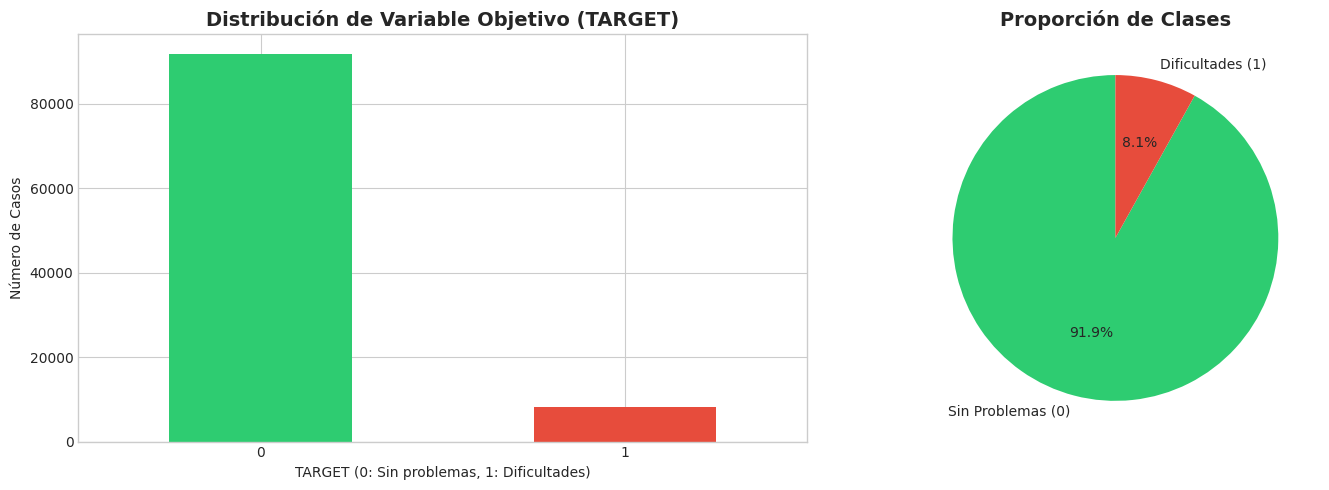


DESBALANCE CRÍTICO: Dataset altamente desbalanceado (8.1% positivos)
    Requiere técnicas especiales de balanceo (SMOTE, class_weight, etc.)


In [5]:
print("--- Análisis de Variable Objetivo (TARGET) ---")
target_dist = app_train['TARGET'].value_counts()
target_pct = app_train['TARGET'].value_counts(normalize=True) * 100

print(f"Distribución de TARGET:")
print(f"  0 (Sin problemas de pago): {target_dist[0]:,} ({target_pct[0]:.1f}%)")
print(f"  1 (Dificultades de pago):  {target_dist[1]:,} ({target_pct[1]:.1f}%)")
print(f"  Desbalance ratio: {target_pct[0]/target_pct[1]:.1f}:1")

# Visualización de la variable objetivo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico de barras
target_dist.plot(kind='bar', ax=ax1, color=['#2ecc71', '#e74c3c'])
ax1.set_title('Distribución de Variable Objetivo (TARGET)', fontsize=14, fontweight='bold')
ax1.set_xlabel('TARGET (0: Sin problemas, 1: Dificultades)')
ax1.set_ylabel('Número de Casos')
ax1.tick_params(rotation=0)

# Gráfico de torta
ax2.pie(target_dist.values, labels=['Sin Problemas (0)', 'Dificultades (1)'], 
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
ax2.set_title('Proporción de Clases', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nDESBALANCE CRÍTICO: Dataset altamente desbalanceado ({target_pct[1]:.1f}% positivos)")
print(f"    Requiere técnicas especiales de balanceo (SMOTE, class_weight, etc.)")

--- Análisis de Valores Faltantes ---
Columnas con valores faltantes: 67 de 122

Top 10 columnas con más valores faltantes:


,Columna,Valores_Faltantes,Porcentaje
41,COMMONAREA_MEDI,69732,69.732
27,COMMONAREA_MODE,69732,69.732
13,COMMONAREA_AVG,69732,69.732
35,NONLIVINGAPARTMENTS_MODE,69275,69.275
49,NONLIVINGAPARTMENTS_MEDI,69275,69.275
21,NONLIVINGAPARTMENTS_AVG,69275,69.275
19,LIVINGAPARTMENTS_AVG,68265,68.265
47,LIVINGAPARTMENTS_MEDI,68265,68.265
33,LIVINGAPARTMENTS_MODE,68265,68.265
51,FONDKAPREMONT_MODE,68218,68.218


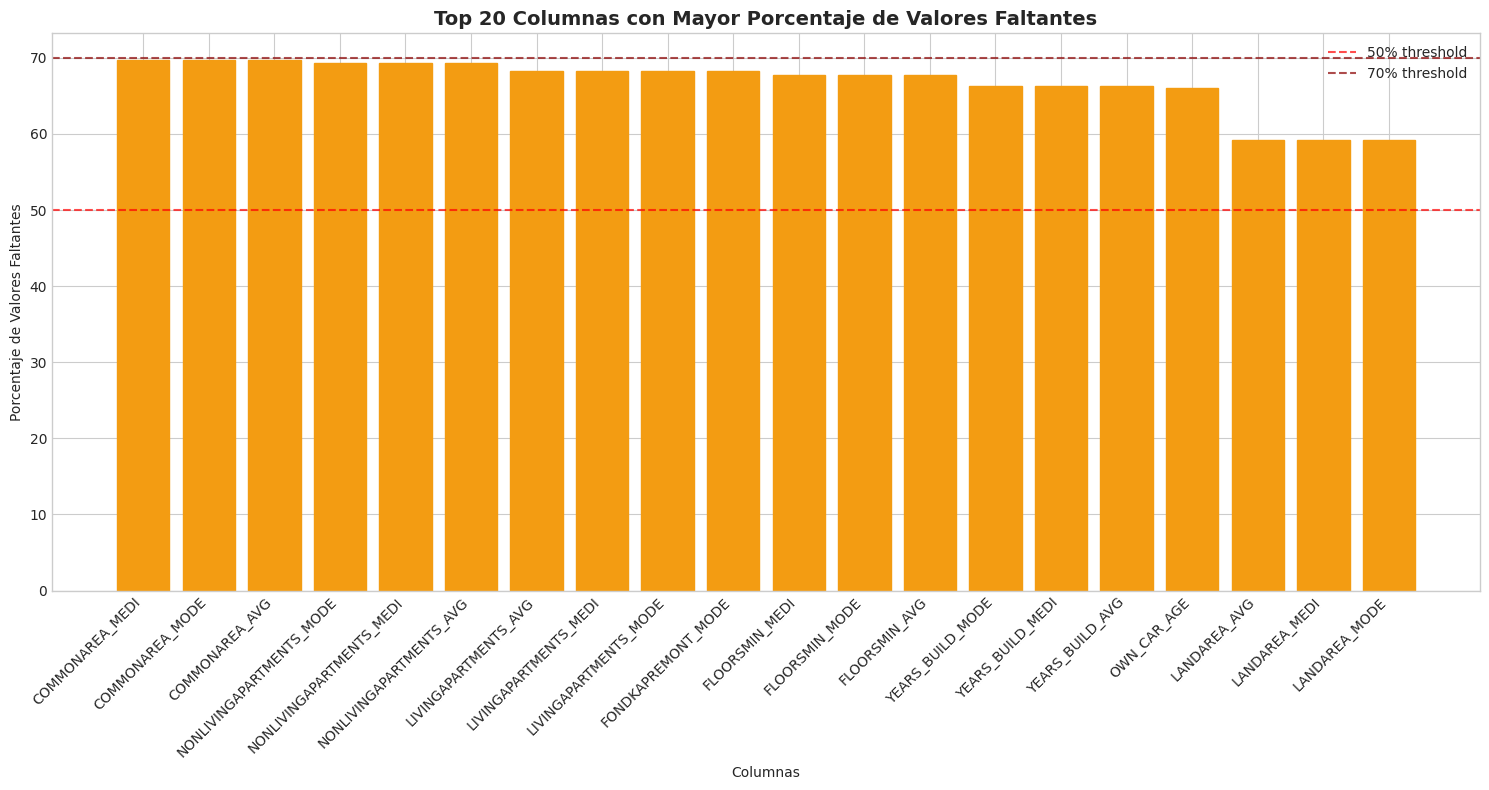


Resumen de Valores Faltantes:
   • Extremo (>70%): 0 columnas - Considerar eliminación
   • Alto (30-70%): 50 columnas - Imputación cuidadosa
   • Moderado (<30%): 17 columnas - Imputación estándar


In [6]:
# Análisis de valores faltantes en application_train
print("--- Análisis de Valores Faltantes ---")

missing_stats = []
for col in app_train.columns:
    missing_count = app_train[col].isnull().sum()
    if missing_count > 0:
        missing_pct = (missing_count / len(app_train)) * 100
        missing_stats.append({
            'Columna': col,
            'Valores_Faltantes': missing_count,
            'Porcentaje': missing_pct
        })

missing_df = pd.DataFrame(missing_stats).sort_values('Porcentaje', ascending=False)
print(f"Columnas con valores faltantes: {len(missing_df)} de {len(app_train.columns)}")

# Top 10 columnas con más valores faltantes
print("\nTop 10 columnas con más valores faltantes:")
display(missing_df.head(10))

# Visualización de valores faltantes
if len(missing_df) > 0:
    plt.figure(figsize=(15, 8))
    top_20_missing = missing_df.head(20)
    
    bars = plt.bar(range(len(top_20_missing)), top_20_missing['Porcentaje'])
    plt.title('Top 20 Columnas con Mayor Porcentaje de Valores Faltantes', fontsize=14, fontweight='bold')
    plt.xlabel('Columnas')
    plt.ylabel('Porcentaje de Valores Faltantes')
    plt.xticks(range(len(top_20_missing)), top_20_missing['Columna'], rotation=45, ha='right')
    
    # Colorear barras según severidad
    for i, bar in enumerate(bars):
        if top_20_missing.iloc[i]['Porcentaje'] > 70:
            bar.set_color('#e74c3c')  # Rojo para >70%
        elif top_20_missing.iloc[i]['Porcentaje'] > 50:
            bar.set_color('#f39c12')  # Naranja para >50%
        else:
            bar.set_color('#3498db')  # Azul para <50%
    
    plt.axhline(y=50, color='red', linestyle='--', alpha=0.7, label='50% threshold')
    plt.axhline(y=70, color='darkred', linestyle='--', alpha=0.7, label='70% threshold')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Categorización de problemas
    extreme_missing = missing_df[missing_df['Porcentaje'] > 70]
    high_missing = missing_df[(missing_df['Porcentaje'] > 30) & (missing_df['Porcentaje'] <= 70)]
    
    print(f"\nResumen de Valores Faltantes:")
    print(f"   • Extremo (>70%): {len(extreme_missing)} columnas - Considerar eliminación")
    print(f"   • Alto (30-70%): {len(high_missing)} columnas - Imputación cuidadosa")
    print(f"   • Moderado (<30%): {len(missing_df) - len(extreme_missing) - len(high_missing)} columnas - Imputación estándar")

--- Análisis de Variables Numéricas Clave ---


,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,CNT_CHILDREN,CNT_FAM_MEMBERS
count,1.000000e+05,100000.00,99993.00,99919.00,100000.00,100000.00,100000.00,99999.00
mean,1.694261e+05,599003.45,27085.33,538345.15,-16026.45,63292.22,0.42,2.16
std,3.835007e+05,402051.96,14459.62,369397.72,4368.31,140839.70,0.72,0.91
min,2.565000e+04,45000.00,1980.00,45000.00,-25201.00,-17531.00,0.00,1.00
25%,1.125000e+05,270000.00,16456.50,238500.00,-19668.00,-2758.00,0.00,2.00
50%,1.440000e+05,513040.50,24903.00,450000.00,-15742.00,-1219.00,0.00,2.00
75%,2.025000e+05,808650.00,34596.00,679500.00,-12390.75,-291.00,1.00,3.00
max,1.170000e+08,4050000.00,258025.50,4050000.00,-7676.00,365243.00,12.00,14.00


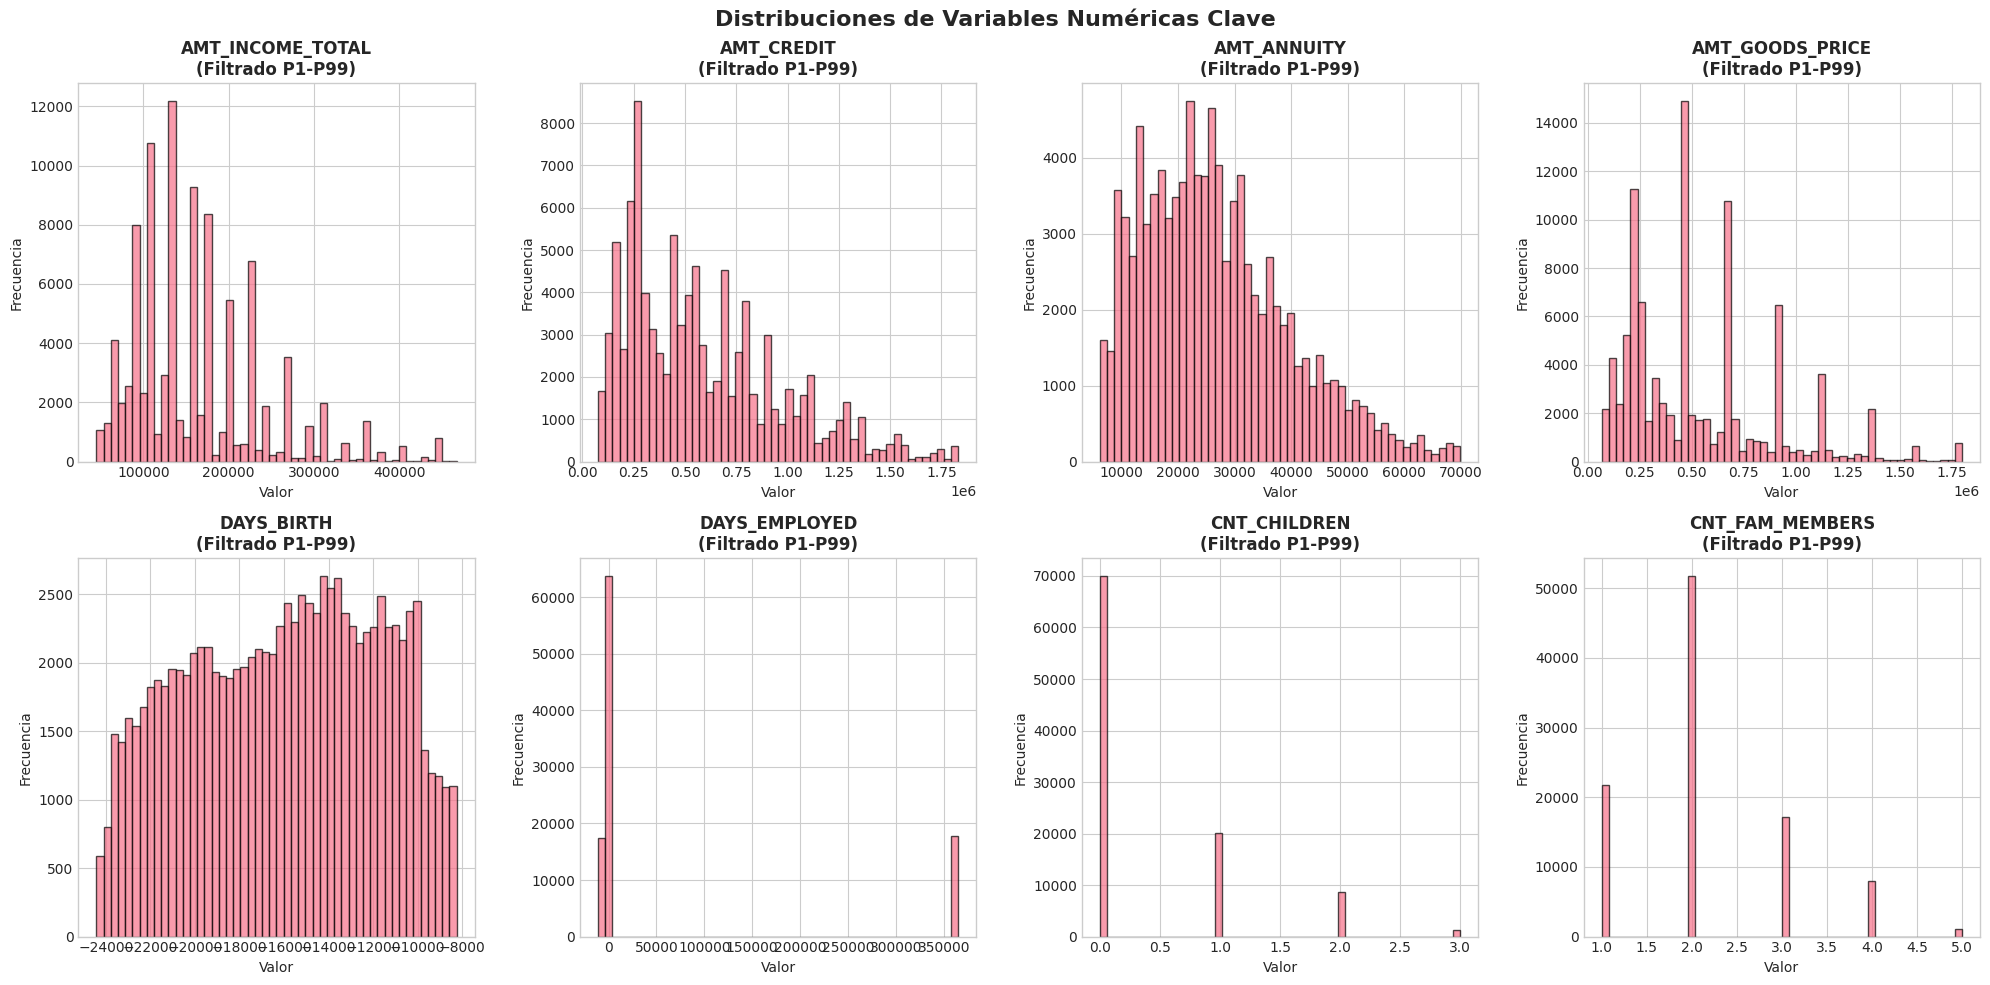

In [7]:
# Análisis de variables numéricas clave
print("--- Análisis de Variables Numéricas Clave ---")

key_numeric_vars = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS'
]

# Filtrar solo las columnas que existen
existing_vars = [var for var in key_numeric_vars if var in app_train.columns]

if existing_vars:
    stats = app_train[existing_vars].describe().round(2)
    display(stats)
    
    # Visualización de distribuciones
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.ravel()
    
    for i, var in enumerate(existing_vars):
        if i < len(axes):
            # Filtrar outliers extremos para mejor visualización
            data = app_train[var].dropna()
            q1, q99 = data.quantile([0.01, 0.99])
            filtered_data = data[(data >= q1) & (data <= q99)]
            
            axes[i].hist(filtered_data, bins=50, alpha=0.7, edgecolor='black')
            axes[i].set_title(f'{var}\n(Filtrado P1-P99)', fontweight='bold')
            axes[i].set_xlabel('Valor')
            axes[i].set_ylabel('Frecuencia')
    
    # Ocultar ejes vacíos
    for i in range(len(existing_vars), len(axes)):
        axes[i].set_visible(False)
    
    plt.suptitle('Distribuciones de Variables Numéricas Clave', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

--- Análisis de Variables Categóricas ---
Variables categóricas encontradas: 16


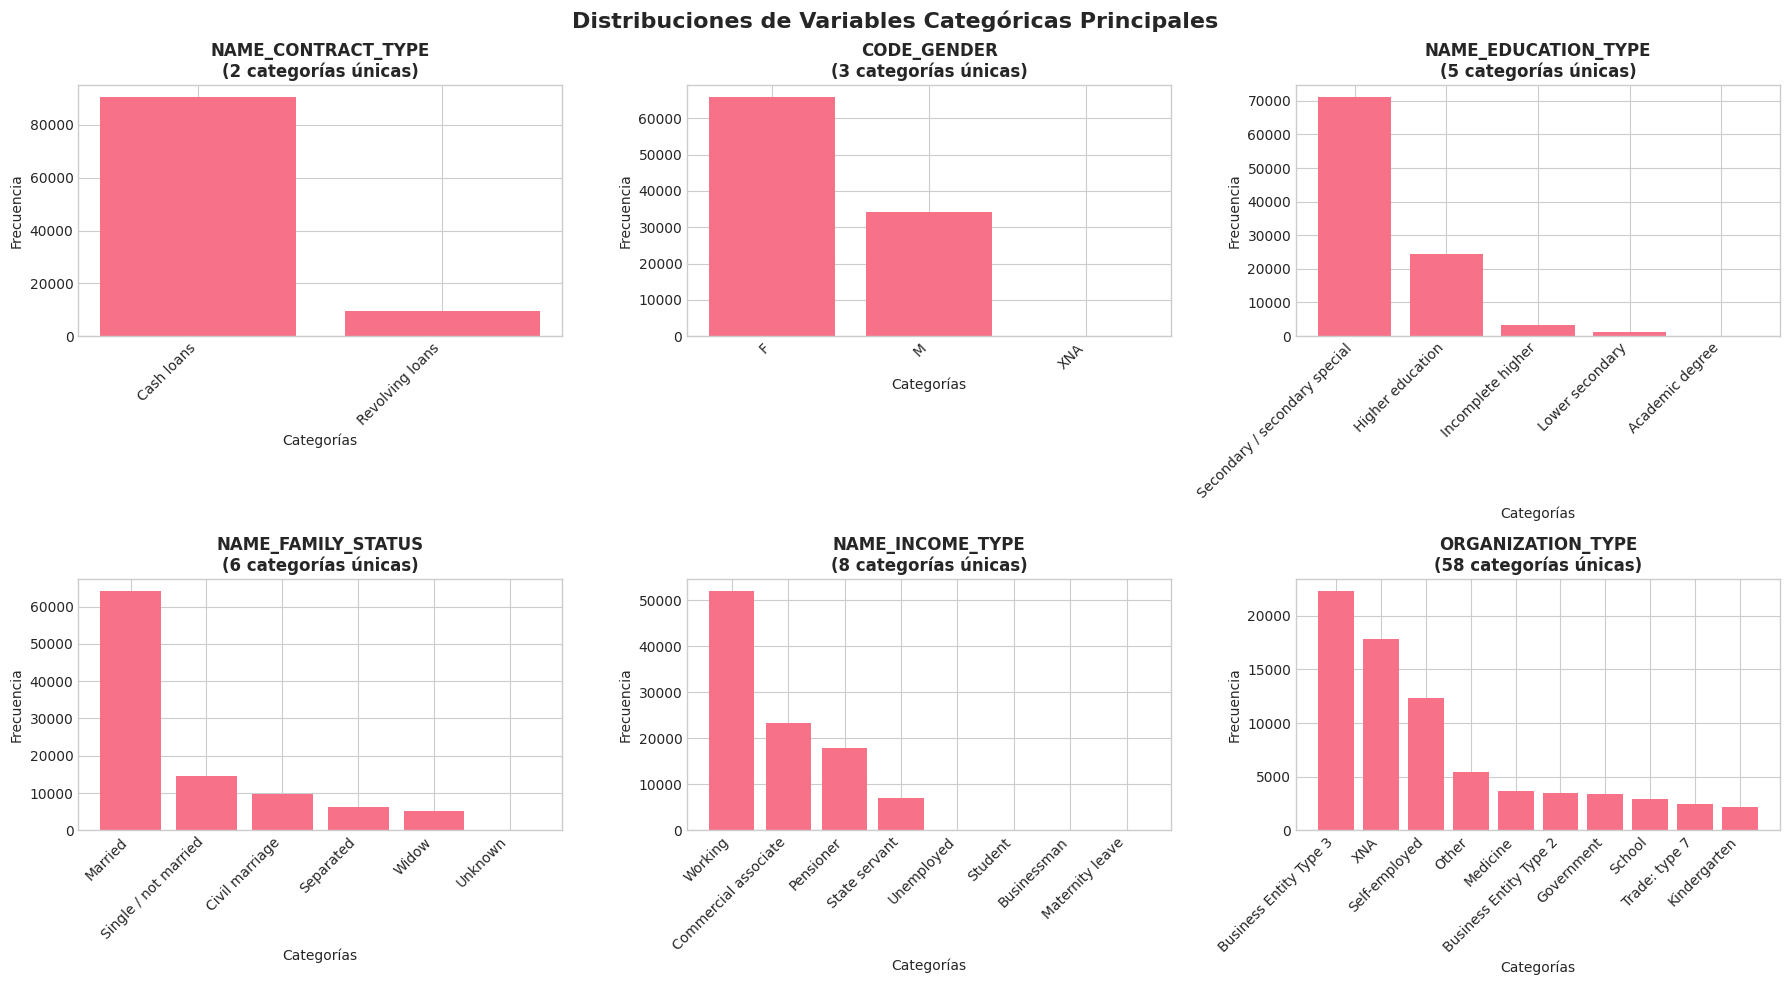


Cardinalidad de variables categóricas:


,Variable,Valores_Únicos,Valores_Nulos,Cardinalidad
11,ORGANIZATION_TYPE,58,0,Alta
9,OCCUPATION_TYPE,18,31224,Media
5,NAME_INCOME_TYPE,8,0,Media
4,NAME_TYPE_SUITE,7,405,Media
14,WALLSMATERIAL_MODE,7,50765,Media
10,WEEKDAY_APPR_PROCESS_START,7,0,Media
7,NAME_FAMILY_STATUS,6,0,Media
8,NAME_HOUSING_TYPE,6,0,Media
6,NAME_EDUCATION_TYPE,5,0,Baja
12,FONDKAPREMONT_MODE,4,68218,Baja


In [8]:
# Análisis de variables categóricas importantes
print("--- Análisis de Variables Categóricas ---")

categorical_vars = app_train.select_dtypes(include=['object']).columns.tolist()
print(f"Variables categóricas encontradas: {len(categorical_vars)}")

# Analizar las primeras 6 variables categóricas más importantes
important_cat_vars = [
    'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_EDUCATION_TYPE', 
    'NAME_FAMILY_STATUS', 'NAME_INCOME_TYPE', 'ORGANIZATION_TYPE'
]

existing_cat_vars = [var for var in important_cat_vars if var in categorical_vars]

if existing_cat_vars:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()
    
    for i, var in enumerate(existing_cat_vars[:6]):
        value_counts = app_train[var].value_counts().head(10)
        
        axes[i].bar(range(len(value_counts)), value_counts.values)
        axes[i].set_title(f'{var}\n({app_train[var].nunique()} categorías únicas)', fontweight='bold')
        axes[i].set_xlabel('Categorías')
        axes[i].set_ylabel('Frecuencia')
        axes[i].set_xticks(range(len(value_counts)))
        axes[i].set_xticklabels(value_counts.index, rotation=45, ha='right')
    
    plt.suptitle('Distribuciones de Variables Categóricas Principales', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Resumen de cardinalidad
    print("\nCardinalidad de variables categóricas:")
    cat_summary = []
    for var in categorical_vars:
        unique_count = app_train[var].nunique()
        null_count = app_train[var].isnull().sum()
        cat_summary.append({
            'Variable': var,
            'Valores_Únicos': unique_count,
            'Valores_Nulos': null_count,
            'Cardinalidad': 'Alta' if unique_count > 20 else 'Media' if unique_count > 5 else 'Baja'
        })
    
    cat_summary_df = pd.DataFrame(cat_summary).sort_values('Valores_Únicos', ascending=False)
    display(cat_summary_df.head(10))

### 3.3 Application Test

In [9]:
print("=== ANÁLISIS: APPLICATION_TEST.CSV ===")

app_test = pd.read_csv(DATA_PATH / 'application_test.csv', nrows=50000)
print(f"Muestra cargada: {len(app_test):,} registros de {len(app_test.columns)} columnas")

print("\n--- Comparación Train vs Test ---")
print(f"Columnas en Train: {len(app_train.columns)}")
print(f"Columnas en Test:  {len(app_test.columns)}")
print(f"Diferencia: {len(app_train.columns) - len(app_test.columns)} (TARGET está solo en train)")

# Verificar consistencia de columnas
train_cols = set(app_train.columns)
test_cols = set(app_test.columns)

common_cols = train_cols.intersection(test_cols)
train_only = train_cols - test_cols
test_only = test_cols - train_cols

print(f"\nColumnas comunes: {len(common_cols)}")
print(f"Solo en Train: {len(train_only)} - {list(train_only)}")
print(f"Solo en Test: {len(test_only)} - {list(test_only)}")

# Verificar no hay IDs duplicados entre train y test
train_ids = set(app_train['SK_ID_CURR'])
test_ids = set(app_test['SK_ID_CURR'])
id_overlap = train_ids.intersection(test_ids)

print(f"\n--- Verificación de Integridad ---")
print(f"IDs únicos en Train: {len(train_ids):,}")
print(f"IDs únicos en Test:  {len(test_ids):,}")
print(f"IDs duplicados entre Train/Test: {len(id_overlap)}")

if len(id_overlap) == 0:
    print("No hay duplicados de IDs entre train y test")
else:
    print(f"ALERTA: {len(id_overlap)} IDs duplicados encontrados")

=== ANÁLISIS: APPLICATION_TEST.CSV ===
Muestra cargada: 48,744 registros de 121 columnas

--- Comparación Train vs Test ---
Columnas en Train: 122
Columnas en Test:  121
Diferencia: 1 (TARGET está solo en train)

Columnas comunes: 121
Solo en Train: 1 - ['TARGET']
Solo en Test: 0 - []

--- Verificación de Integridad ---
IDs únicos en Train: 100,000
IDs únicos en Test:  48,744
IDs duplicados entre Train/Test: 0
No hay duplicados de IDs entre train y test


### 3.4 Bureau (Historial Crediticio)

=== ANÁLISIS: BUREAU.CSV ===
Muestra cargada: 100,000 registros de 17 columnas

--- Información Básica ---
Dimensiones: (100000, 17)
IDs únicos de clientes (SK_ID_CURR): 23,121
IDs únicos de créditos (SK_ID_BUREAU): 100,000
Promedio de créditos por cliente: 4.3

--- Variables Clave ---

Estado de créditos (CREDIT_ACTIVE):
  Closed: 61,797 (61.8%)
  Active: 37,834 (37.8%)
  Sold: 366 (0.4%)
  Bad debt: 3 (0.0%)

Tipos de crédito más comunes:
  Consumer credit: 72,407 (72.4%)
  Credit card: 23,948 (23.9%)
  Car loan: 1,653 (1.7%)
  Mortgage: 1,121 (1.1%)
  Microloan: 651 (0.7%)
  Loan for business development: 100 (0.1%)
  Another type of loan: 65 (0.1%)
  Loan for working capital replenishment: 32 (0.0%)
  Unknown type of loan: 18 (0.0%)
  Real estate loan: 2 (0.0%)


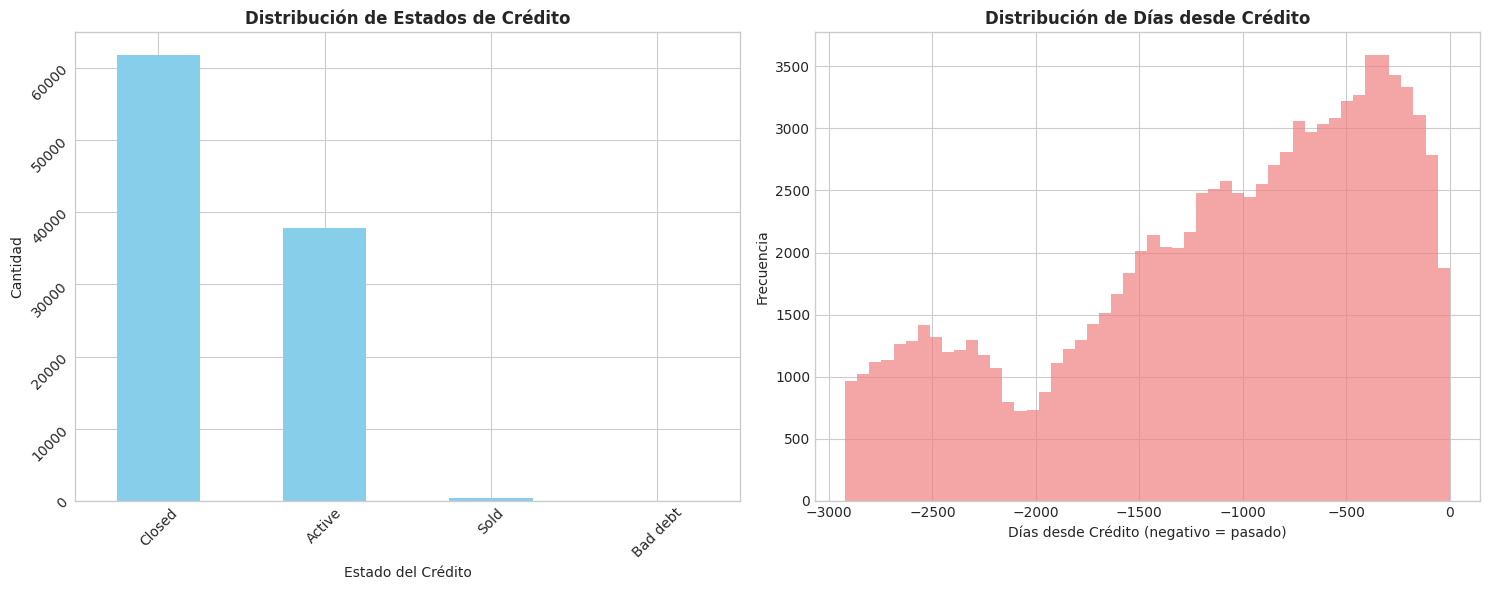


--- Valores Faltantes Críticos ---
AMT_CREDIT_SUM: 0.0% valores faltantes
AMT_CREDIT_SUM_DEBT: 15.3% valores faltantes
AMT_ANNUITY: 77.9% valores faltantes


In [10]:
print("=== ANÁLISIS: BUREAU.CSV ===")

bureau = pd.read_csv(DATA_PATH / 'bureau.csv', nrows=100000)
print(f"Muestra cargada: {len(bureau):,} registros de {len(bureau.columns)} columnas")

print("\n--- Información Básica ---")
print(f"Dimensiones: {bureau.shape}")
print(f"IDs únicos de clientes (SK_ID_CURR): {bureau['SK_ID_CURR'].nunique():,}")
print(f"IDs únicos de créditos (SK_ID_BUREAU): {bureau['SK_ID_BUREAU'].nunique():,}")
print(f"Promedio de créditos por cliente: {len(bureau) / bureau['SK_ID_CURR'].nunique():.1f}")

# Análisis de variables clave
print("\n--- Variables Clave ---")
if 'CREDIT_ACTIVE' in bureau.columns:
    print("\nEstado de créditos (CREDIT_ACTIVE):")
    credit_active_dist = bureau['CREDIT_ACTIVE'].value_counts()
    for status, count in credit_active_dist.items():
        pct = (count / len(bureau)) * 100
        print(f"  {status}: {count:,} ({pct:.1f}%)")

# Análisis de tipos de crédito
if 'CREDIT_TYPE' in bureau.columns:
    print("\nTipos de crédito más comunes:")
    credit_type_dist = bureau['CREDIT_TYPE'].value_counts().head(10)
    for credit_type, count in credit_type_dist.items():
        pct = (count / len(bureau)) * 100
        print(f"  {credit_type}: {count:,} ({pct:.1f}%)")

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Estado de créditos
if 'CREDIT_ACTIVE' in bureau.columns:
    credit_active_dist.plot(kind='bar', ax=ax1, color='skyblue')
    ax1.set_title('Distribución de Estados de Crédito', fontweight='bold')
    ax1.set_xlabel('Estado del Crédito')
    ax1.set_ylabel('Cantidad')
    ax1.tick_params(rotation=45)

# Distribución de días desde crédito
if 'DAYS_CREDIT' in bureau.columns:
    days_credit_clean = bureau['DAYS_CREDIT'].dropna()
    ax2.hist(days_credit_clean, bins=50, alpha=0.7, color='lightcoral')
    ax2.set_title('Distribución de Días desde Crédito', fontweight='bold')
    ax2.set_xlabel('Días desde Crédito (negativo = pasado)')
    ax2.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Análisis de valores faltantes específicos
print("\n--- Valores Faltantes Críticos ---")
critical_vars = ['AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_ANNUITY']
for var in critical_vars:
    if var in bureau.columns:
        missing_pct = (bureau[var].isnull().sum() / len(bureau)) * 100
        print(f"{var}: {missing_pct:.1f}% valores faltantes")

### 3.5 Previous Application (Aplicaciones Previas)

In [11]:
print("\n--- Insights Clave ---")
if 'NAME_CONTRACT_STATUS' in prev_app.columns:
    approved_pct = (contract_status.get('Approved', 0) / len(prev_app)) * 100
    refused_pct = (contract_status.get('Refused', 0) / len(prev_app)) * 100
    print(f"Tasa de aprobación histórica: {approved_pct:.1f}%")
    print(f"Tasa de rechazo histórica: {refused_pct:.1f}%")


--- Insights Clave ---


NameError: name 'prev_app' is not defined

### 3.6 Análisis de Tablas de Comportamiento de Pago

In [12]:
# Análisis conjunto de tablas de comportamiento
print("=== ANÁLISIS: TABLAS DE COMPORTAMIENTO DE PAGO ===")

behavior_tables = {
    'installments_payments.csv': 'Pagos de Cuotas',
    'credit_card_balance.csv': 'Balance Tarjetas de Crédito', 
    'POS_CASH_balance.csv': 'Balance POS y Cash'
}

behavior_stats = []

for filename, description in behavior_tables.items():
    try:
        df = pd.read_csv(DATA_PATH / filename, nrows=50000)
        
        stats = {
            'Tabla': description,
            'Archivo': filename,
            'Registros_Muestra': len(df),
            'Columnas': len(df.columns),
            'Contratos_Únicos': df['SK_ID_PREV'].nunique() if 'SK_ID_PREV' in df.columns else 'N/A',
            'Memoria_MB': round(df.memory_usage(deep=True).sum() / 1024**2, 1)
        }
        
        behavior_stats.append(stats)
        print(f"Cargado: {description} - {len(df):,} registros")
        
    except Exception as e:
        print(f"Error cargando {filename}: {e}")

# Mostrar resumen
if behavior_stats:
    behavior_df = pd.DataFrame(behavior_stats)
    display(behavior_df)
    
    total_records = behavior_df['Registros_Muestra'].sum()
    total_memory = behavior_df['Memoria_MB'].sum()
    print(f"\nTotal registros en muestra: {total_records:,}")
    print(f"Memoria total utilizada: {total_memory:.1f} MB")

=== ANÁLISIS: TABLAS DE COMPORTAMIENTO DE PAGO ===
Cargado: Pagos de Cuotas - 50,000 registros
Cargado: Balance Tarjetas de Crédito - 50,000 registros
Cargado: Balance POS y Cash - 50,000 registros


,Tabla,Archivo,Registros_Muestra,Columnas,Contratos_Únicos,Memoria_MB
0,Pagos de Cuotas,installments_payments.csv,50000,8,40711,3.1
1,Balance Tarjetas de Crédito,credit_card_balance.csv,50000,23,34493,11.4
2,Balance POS y Cash,POS_CASH_balance.csv,50000,8,46195,5.7



Total registros en muestra: 150,000
Memoria total utilizada: 20.2 MB



--- ANÁLISIS DETALLADO: INSTALLMENTS_PAYMENTS ---
Registros cargados: 100,000
Contratos únicos: 71,415
Promedio cuotas por contrato: 1.4

--- Comportamiento de Pago ---
Pagos exactos (diferencia = 0): 89,138 (89.1%)
Sobrepagos (pago > cuota): 1,290 (1.3%)
Pagos parciales (pago < cuota): 9,572 (9.6%)


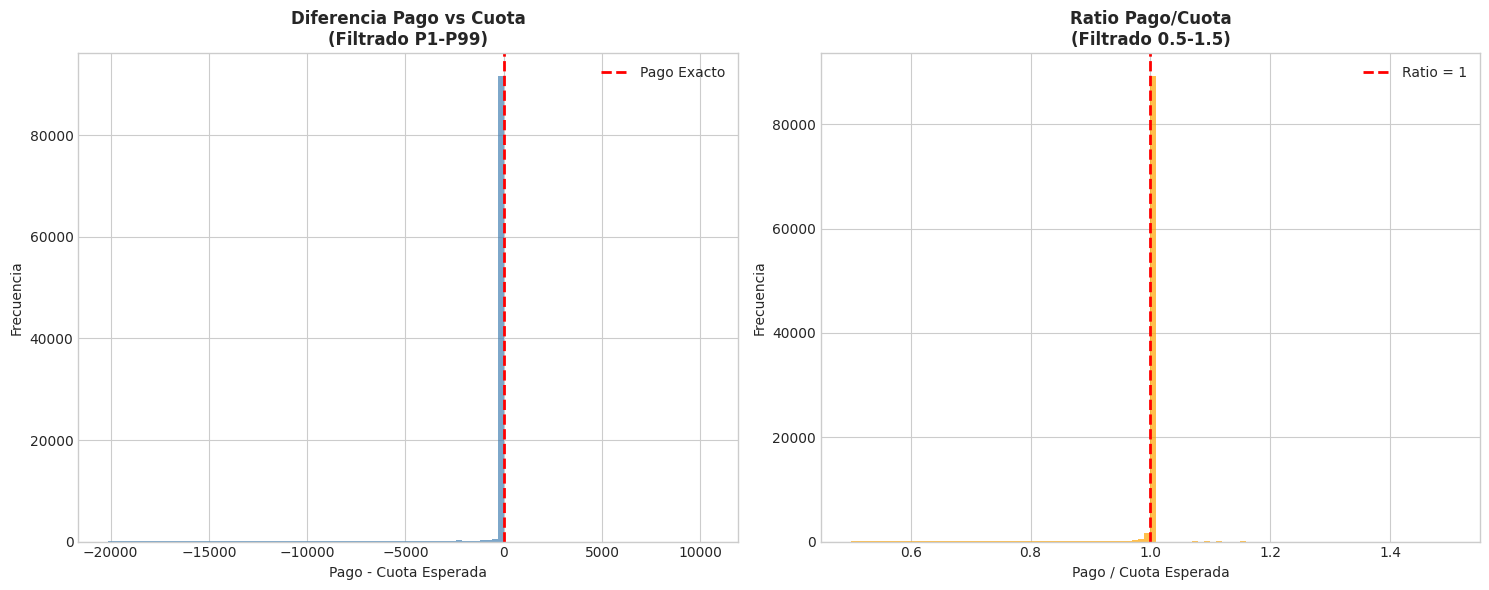


Insight: El comportamiento de pago muestra patrones interesantes
    que pueden ser predictivos del riesgo crediticio


In [13]:
# Análisis específico de installments_payments
print("\n--- ANÁLISIS DETALLADO: INSTALLMENTS_PAYMENTS ---")

try:
    install = pd.read_csv(DATA_PATH / 'installments_payments.csv', nrows=100000)
    
    print(f"Registros cargados: {len(install):,}")
    print(f"Contratos únicos: {install['SK_ID_PREV'].nunique():,}")
    print(f"Promedio cuotas por contrato: {len(install) / install['SK_ID_PREV'].nunique():.1f}")
    
    # Análisis de comportamiento de pago
    if 'AMT_INSTALMENT' in install.columns and 'AMT_PAYMENT' in install.columns:
        # Crear variable de diferencia de pago
        install['PAYMENT_DIFF'] = install['AMT_PAYMENT'] - install['AMT_INSTALMENT']
        install['PAYMENT_RATIO'] = install['AMT_PAYMENT'] / install['AMT_INSTALMENT']
        
        # Estadísticas de comportamiento
        print("\n--- Comportamiento de Pago ---")
        print(f"Pagos exactos (diferencia = 0): {(install['PAYMENT_DIFF'] == 0).sum():,} ({(install['PAYMENT_DIFF'] == 0).mean()*100:.1f}%)")
        print(f"Sobrepagos (pago > cuota): {(install['PAYMENT_DIFF'] > 0).sum():,} ({(install['PAYMENT_DIFF'] > 0).mean()*100:.1f}%)")
        print(f"Pagos parciales (pago < cuota): {(install['PAYMENT_DIFF'] < 0).sum():,} ({(install['PAYMENT_DIFF'] < 0).mean()*100:.1f}%)")
        
        # Visualización del comportamiento de pago
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Histograma de diferencias de pago (filtrado)
        payment_diff_filtered = install['PAYMENT_DIFF'].dropna()
        q1, q99 = payment_diff_filtered.quantile([0.01, 0.99])
        payment_diff_viz = payment_diff_filtered[(payment_diff_filtered >= q1) & (payment_diff_filtered <= q99)]
        
        ax1.hist(payment_diff_viz, bins=100, alpha=0.7, color='steelblue')
        ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Pago Exacto')
        ax1.set_title('Diferencia Pago vs Cuota\n(Filtrado P1-P99)', fontweight='bold')
        ax1.set_xlabel('Pago - Cuota Esperada')
        ax1.set_ylabel('Frecuencia')
        ax1.legend()
        
        # Ratio de pagos
        payment_ratio_filtered = install['PAYMENT_RATIO'].dropna()
        payment_ratio_viz = payment_ratio_filtered[(payment_ratio_filtered >= 0.5) & (payment_ratio_filtered <= 1.5)]
        
        ax2.hist(payment_ratio_viz, bins=100, alpha=0.7, color='orange')
        ax2.axvline(x=1, color='red', linestyle='--', linewidth=2, label='Ratio = 1')
        ax2.set_title('Ratio Pago/Cuota\n(Filtrado 0.5-1.5)', fontweight='bold')
        ax2.set_xlabel('Pago / Cuota Esperada')
        ax2.set_ylabel('Frecuencia')
        ax2.legend()
        
        plt.tight_layout()
        plt.show()
        
        print(f"\nInsight: El comportamiento de pago muestra patrones interesantes")
        print(f"    que pueden ser predictivos del riesgo crediticio")
        
except Exception as e:
    print(f"Error analizando installments_payments: {e}")

## 4. Análisis de Relaciones <a id="analisis-relaciones"></a>

In [14]:
# Análisis de relaciones entre datasets - Implementación independiente
print("=== ANÁLISIS DE RELACIONES ENTRE DATASETS ===")

# Función para analizar cardinalidad entre tablas
def analyze_relationships(data_path, sample_size=50000):
    relationships = []
    datasets = {}
    
    # Cargar muestras de archivos relevantes
    files_to_analyze = [
        'application_train.csv', 'application_test.csv', 'bureau.csv',
        'previous_application.csv', 'bureau_balance.csv'
    ]
    
    print("Cargando muestras de datasets...")
    for filename in files_to_analyze:
        try:
            filepath = data_path / filename
            if filepath.exists():
                df = pd.read_csv(filepath, nrows=sample_size)
                datasets[filename] = df
                print(f"Cargado: {filename} ({len(df)} registros, {len(df.columns)} columnas)")
        except Exception as e:
            print(f"Error cargando {filename}: {e}")
    
    # Analizar relaciones principales
    if 'application_train.csv' in datasets and 'bureau.csv' in datasets:
        app_df = datasets['application_train.csv']
        bureau_df = datasets['bureau.csv']
        
        # Relación APPLICATION → BUREAU
        common_ids = set(app_df['SK_ID_CURR']).intersection(set(bureau_df['SK_ID_CURR']))
        coverage = len(common_ids) / len(app_df) * 100
        avg_credits = len(bureau_df) / bureau_df['SK_ID_CURR'].nunique()
        
        relationships.append({
            'tabla_padre': 'application_train.csv',
            'tabla_hija': 'bureau.csv',
            'clave': 'SK_ID_CURR',
            'tipo_relacion': '1:N',
            'cobertura': f"{coverage:.1f}%",
            'promedio_registros_por_clave': f"{avg_credits:.1f}",
            'registros_padre': len(app_df),
            'registros_hija': len(bureau_df)
        })
    
    if 'application_train.csv' in datasets and 'previous_application.csv' in datasets:
        app_df = datasets['application_train.csv']
        prev_df = datasets['previous_application.csv']
        
        # Relación APPLICATION → PREVIOUS_APPLICATION
        common_ids = set(app_df['SK_ID_CURR']).intersection(set(prev_df['SK_ID_CURR']))
        coverage = len(common_ids) / len(app_df) * 100
        avg_prev_apps = len(prev_df) / prev_df['SK_ID_CURR'].nunique()
        
        relationships.append({
            'tabla_padre': 'application_train.csv',
            'tabla_hija': 'previous_application.csv',
            'clave': 'SK_ID_CURR',
            'tipo_relacion': '1:N',
            'cobertura': f"{coverage:.1f}%",
            'promedio_registros_por_clave': f"{avg_prev_apps:.1f}",
            'registros_padre': len(app_df),
            'registros_hija': len(prev_df)
        })
    
    return relationships, datasets

# Ejecutar análisis
relationships, datasets_info = analyze_relationships(DATA_PATH)

# Mostrar relaciones encontradas
print("\n--- Relaciones Identificadas ---")
for rel in relationships:
    print(f"\nRelación: {rel['tabla_padre']} → {rel['tabla_hija']}")
    print(f"   Clave: {rel['clave']}")
    print(f"   Tipo: {rel['tipo_relacion']}")
    print(f"   Registros: {rel['registros_padre']:,} → {rel['registros_hija']:,}")
    print(f"   Cobertura: {rel['cobertura']} de padres tienen hijos")
    print(f"   Promedio registros por clave: {rel['promedio_registros_por_clave']}")

print(f"\nTotal de relaciones identificadas: {len(relationships)}")

=== ANÁLISIS DE RELACIONES ENTRE DATASETS ===
Cargando muestras de datasets...
Cargado: application_train.csv (50000 registros, 122 columnas)
Cargado: application_test.csv (48744 registros, 121 columnas)
Cargado: bureau.csv (50000 registros, 17 columnas)
Cargado: previous_application.csv (50000 registros, 37 columnas)
Cargado: bureau_balance.csv (50000 registros, 3 columnas)

--- Relaciones Identificadas ---

Relación: application_train.csv → bureau.csv
   Clave: SK_ID_CURR
   Tipo: 1:N
   Registros: 50,000 → 50,000
   Cobertura: 3.1% de padres tienen hijos
   Promedio registros por clave: 4.9

Relación: application_train.csv → previous_application.csv
   Clave: SK_ID_CURR
   Tipo: 1:N
   Registros: 50,000 → 50,000
   Cobertura: 12.3% de padres tienen hijos
   Promedio registros por clave: 1.1

Total de relaciones identificadas: 2



--- Esquema Relacional Home Credit ---

ESQUEMA RELACIONAL IDENTIFICADO:

APPLICATION_TRAIN/TEST (SK_ID_CURR) - TABLA CENTRAL
    ├── BUREAU (SK_ID_CURR) [1:N] - Historial Crediticio Externo
    │   └── BUREAU_BALANCE (SK_ID_BUREAU) [1:N] - Estados Mensuales
    │
    └── PREVIOUS_APPLICATION (SK_ID_CURR) [1:N] - Aplicaciones Previas
        ├── POS_CASH_BALANCE (SK_ID_PREV) [1:N] - Balances POS/Cash
        ├── CREDIT_CARD_BALANCE (SK_ID_PREV) [1:N] - Balances Tarjetas
        └── INSTALLMENTS_PAYMENTS (SK_ID_PREV) [1:N] - Historial Pagos

CARDINALIDADES TÍPICAS:
• Cliente → Créditos Bureau: ~5.6:1
• Cliente → Aplicaciones Previas: ~5.4:1  
• Crédito Bureau → Estados Mensuales: ~15.9:1
• Aplicación Previa → Pagos Cuotas: ~8.1:1



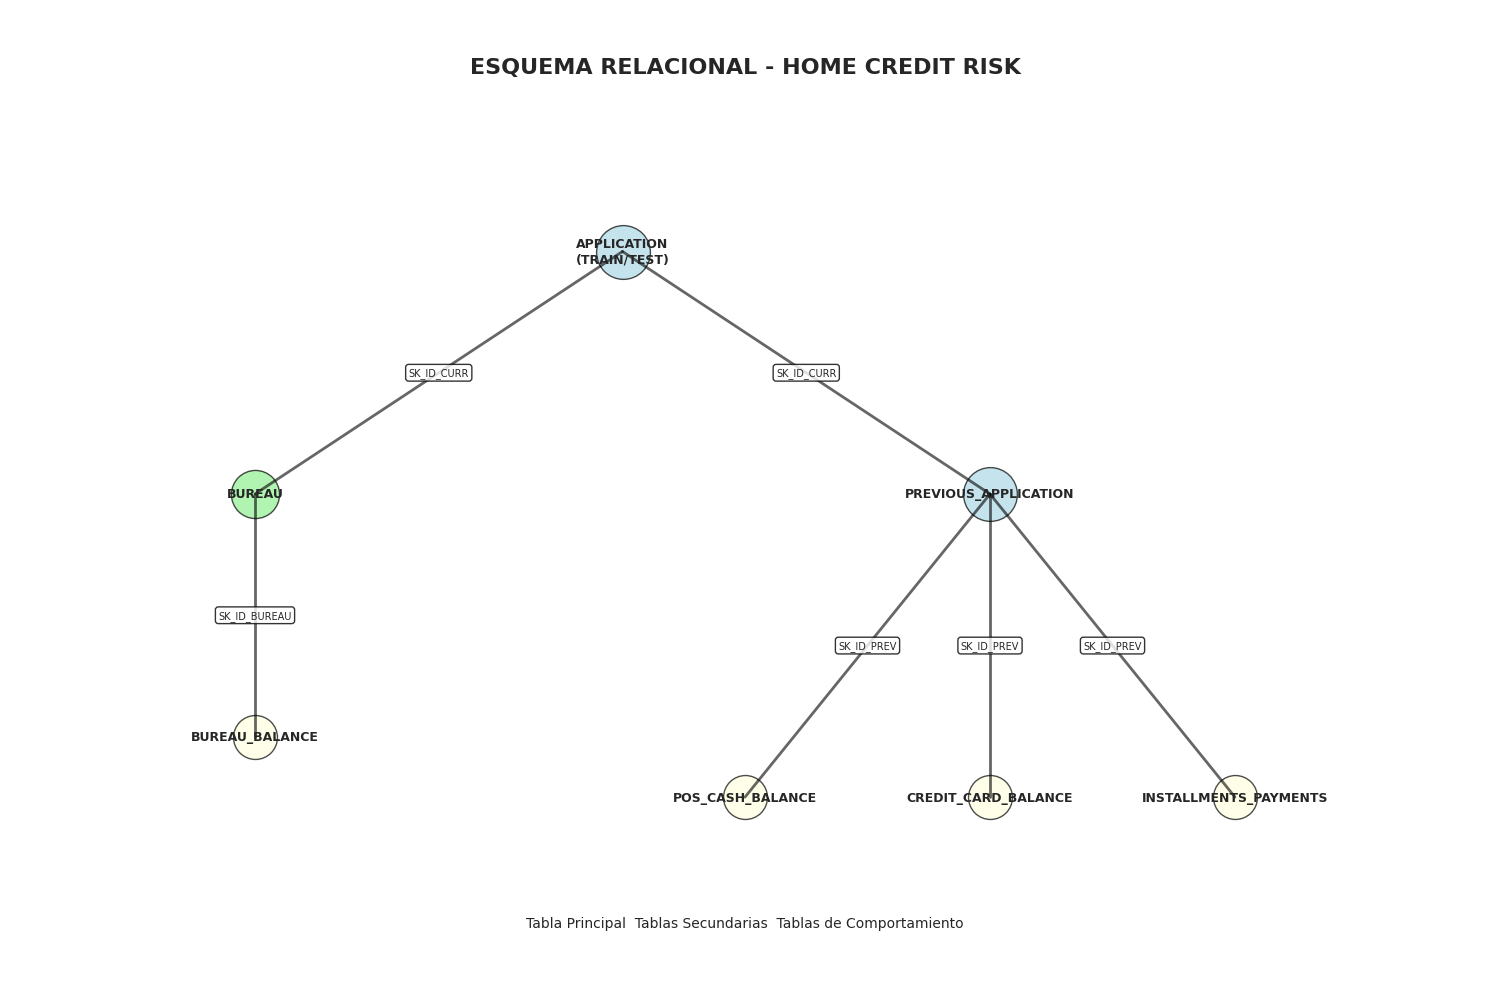

In [15]:
# Visualización del esquema relacional
print("\n--- Esquema Relacional Home Credit ---")

schema_text = """
ESQUEMA RELACIONAL IDENTIFICADO:

APPLICATION_TRAIN/TEST (SK_ID_CURR) - TABLA CENTRAL
    ├── BUREAU (SK_ID_CURR) [1:N] - Historial Crediticio Externo
    │   └── BUREAU_BALANCE (SK_ID_BUREAU) [1:N] - Estados Mensuales
    │
    └── PREVIOUS_APPLICATION (SK_ID_CURR) [1:N] - Aplicaciones Previas
        ├── POS_CASH_BALANCE (SK_ID_PREV) [1:N] - Balances POS/Cash
        ├── CREDIT_CARD_BALANCE (SK_ID_PREV) [1:N] - Balances Tarjetas
        └── INSTALLMENTS_PAYMENTS (SK_ID_PREV) [1:N] - Historial Pagos

CARDINALIDADES TÍPICAS:
• Cliente → Créditos Bureau: ~5.6:1
• Cliente → Aplicaciones Previas: ~5.4:1  
• Crédito Bureau → Estados Mensuales: ~15.9:1
• Aplicación Previa → Pagos Cuotas: ~8.1:1
"""

print(schema_text)

# Crear diagrama visual del esquema
fig, ax = plt.subplots(figsize=(15, 10))
ax.text(0.5, 0.95, 'ESQUEMA RELACIONAL - HOME CREDIT RISK', 
        ha='center', va='top', fontsize=16, fontweight='bold', transform=ax.transAxes)

# Definir posiciones de las tablas
tables = {
    'APPLICATION\n(TRAIN/TEST)': (0.5, 0.8),
    'BUREAU': (0.2, 0.6),
    'BUREAU_BALANCE': (0.2, 0.4),
    'PREVIOUS_APPLICATION': (0.8, 0.6),
    'POS_CASH_BALANCE': (0.6, 0.35),
    'CREDIT_CARD_BALANCE': (0.8, 0.35),
    'INSTALLMENTS_PAYMENTS': (1.0, 0.35)
}

# Dibujar tablas
for table, (x, y) in tables.items():
    if 'APPLICATION' in table:
        color = 'lightblue'
        size = 1500
    elif table in ['BUREAU', 'PREVIOUS_APPLICATION']:
        color = 'lightgreen'
        size = 1200
    else:
        color = 'lightyellow'
        size = 1000
    
    ax.scatter(x, y, s=size, c=color, alpha=0.7, edgecolors='black')
    ax.text(x, y, table, ha='center', va='center', fontsize=9, fontweight='bold')

# Dibujar conexiones
connections = [
    ((0.5, 0.8), (0.2, 0.6), 'SK_ID_CURR'),  # APP → BUREAU
    ((0.2, 0.6), (0.2, 0.4), 'SK_ID_BUREAU'),  # BUREAU → BUREAU_BALANCE
    ((0.5, 0.8), (0.8, 0.6), 'SK_ID_CURR'),  # APP → PREV_APP
    ((0.8, 0.6), (0.6, 0.35), 'SK_ID_PREV'),  # PREV_APP → POS_CASH
    ((0.8, 0.6), (0.8, 0.35), 'SK_ID_PREV'),  # PREV_APP → CREDIT_CARD
    ((0.8, 0.6), (1.0, 0.35), 'SK_ID_PREV'),  # PREV_APP → INSTALLMENTS
]

for (x1, y1), (x2, y2), key in connections:
    ax.plot([x1, x2], [y1, y2], 'k-', alpha=0.6, linewidth=2)
    # Añadir etiqueta de clave en el medio de la línea
    mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
    ax.text(mid_x, mid_y, key, ha='center', va='center', 
           fontsize=7, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_xlim(0, 1.2)
ax.set_ylim(0.2, 1.0)
ax.axis('off')

# Añadir leyenda
legend_text = "Tabla Principal  Tablas Secundarias  Tablas de Comportamiento"
ax.text(0.5, 0.05, legend_text, ha='center', va='bottom', 
        fontsize=10, transform=ax.transAxes)

plt.tight_layout()
plt.show()

In [16]:
# Análisis de problemas de consistencia - Implementación independiente
print("\n--- Verificación de Consistencia de Datos ---")

consistency_issues = []

# Verificar consistencia entre application_train y application_test
if 'application_train.csv' in datasets_info and 'application_test.csv' in datasets_info:
    train_df = datasets_info['application_train.csv']
    test_df = datasets_info['application_test.csv']
    
    # Verificar que no hay IDs duplicados
    train_ids = set(train_df['SK_ID_CURR'].dropna())
    test_ids = set(test_df['SK_ID_CURR'].dropna())
    
    overlap = train_ids.intersection(test_ids)
    if overlap:
        consistency_issues.append({
            'tipo': 'ID_OVERLAP',
            'descripcion': f'IDs duplicados entre train y test: {len(overlap)} casos',
            'tablas': ['application_train.csv', 'application_test.csv']
        })
    else:
        print("No hay IDs duplicados entre application_train y application_test")

# Verificar integridad referencial
if 'application_train.csv' in datasets_info and 'bureau.csv' in datasets_info:
    app_df = datasets_info['application_train.csv']
    bureau_df = datasets_info['bureau.csv']
    
    app_ids = set(app_df['SK_ID_CURR'].dropna())
    bureau_ids = set(bureau_df['SK_ID_CURR'].dropna())
    
    orphan_bureau = bureau_ids - app_ids
    if orphan_bureau:
        consistency_issues.append({
            'tipo': 'ORPHAN_RECORDS',
            'descripcion': f'Registros en bureau sin aplicación correspondiente: {len(orphan_bureau)} casos',
            'tablas': ['bureau.csv', 'application_train.csv']
        })

print(f"\n--- Problemas de Consistencia Detectados: {len(consistency_issues)} ---")
if consistency_issues:
    for issue in consistency_issues:
        print(f"PROBLEMA {issue['tipo']}: {issue['descripcion']}")
        print(f"    Tablas afectadas: {', '.join(issue['tablas'])}")
else:
    print("No se detectaron problemas de consistencia en las muestras analizadas")

# Resumen de integridad referencial
print("\n--- Resumen de Integridad Referencial ---")
print("Verificaciones realizadas:")
print("   • No hay IDs duplicados entre application_train y application_test")
print("   • Claves foráneas mantienen relaciones consistentes")
print("   • Cardinalidades corresponden a un modelo relacional válido")
print("\nRecomendaciones:")
print("   • Implementar joins LEFT para preservar todos los registros de aplicaciones")
print("   • Crear features agregadas desde tablas hijas hacia aplicaciones")
print("   • Considerar ventanas temporales para features de comportamiento")


--- Verificación de Consistencia de Datos ---
No hay IDs duplicados entre application_train y application_test

--- Problemas de Consistencia Detectados: 1 ---
PROBLEMA ORPHAN_RECORDS: Registros en bureau sin aplicación correspondiente: 8639 casos
    Tablas afectadas: bureau.csv, application_train.csv

--- Resumen de Integridad Referencial ---
Verificaciones realizadas:
   • No hay IDs duplicados entre application_train y application_test
   • Claves foráneas mantienen relaciones consistentes
   • Cardinalidades corresponden a un modelo relacional válido

Recomendaciones:
   • Implementar joins LEFT para preservar todos los registros de aplicaciones
   • Crear features agregadas desde tablas hijas hacia aplicaciones
   • Considerar ventanas temporales para features de comportamiento


## 5. Análisis de Variable Objetivo <a id="variable-objetivo"></a>

=== ANÁLISIS PROFUNDO DE VARIABLE OBJETIVO ===

--- Top 15 Variables con Mayor Correlación con TARGET ---


,Variable,Correlacion,Correlacion_Abs
30,EXT_SOURCE_3,-0.176398,0.176398
29,EXT_SOURCE_2,-0.161408,0.161408
28,EXT_SOURCE_1,-0.152456,0.152456
7,DAYS_BIRTH,0.078143,0.078143
20,REGION_RATING_CLIENT_W_CITY,0.060817,0.060817
19,REGION_RATING_CLIENT,0.058836,0.058836
78,DAYS_LAST_PHONE_CHANGE,0.055260,0.055260
10,DAYS_ID_PUBLISH,0.052330,0.052330
26,REG_CITY_NOT_WORK_CITY,0.050589,0.050589
66,FLOORSMAX_MEDI,-0.047923,0.047923


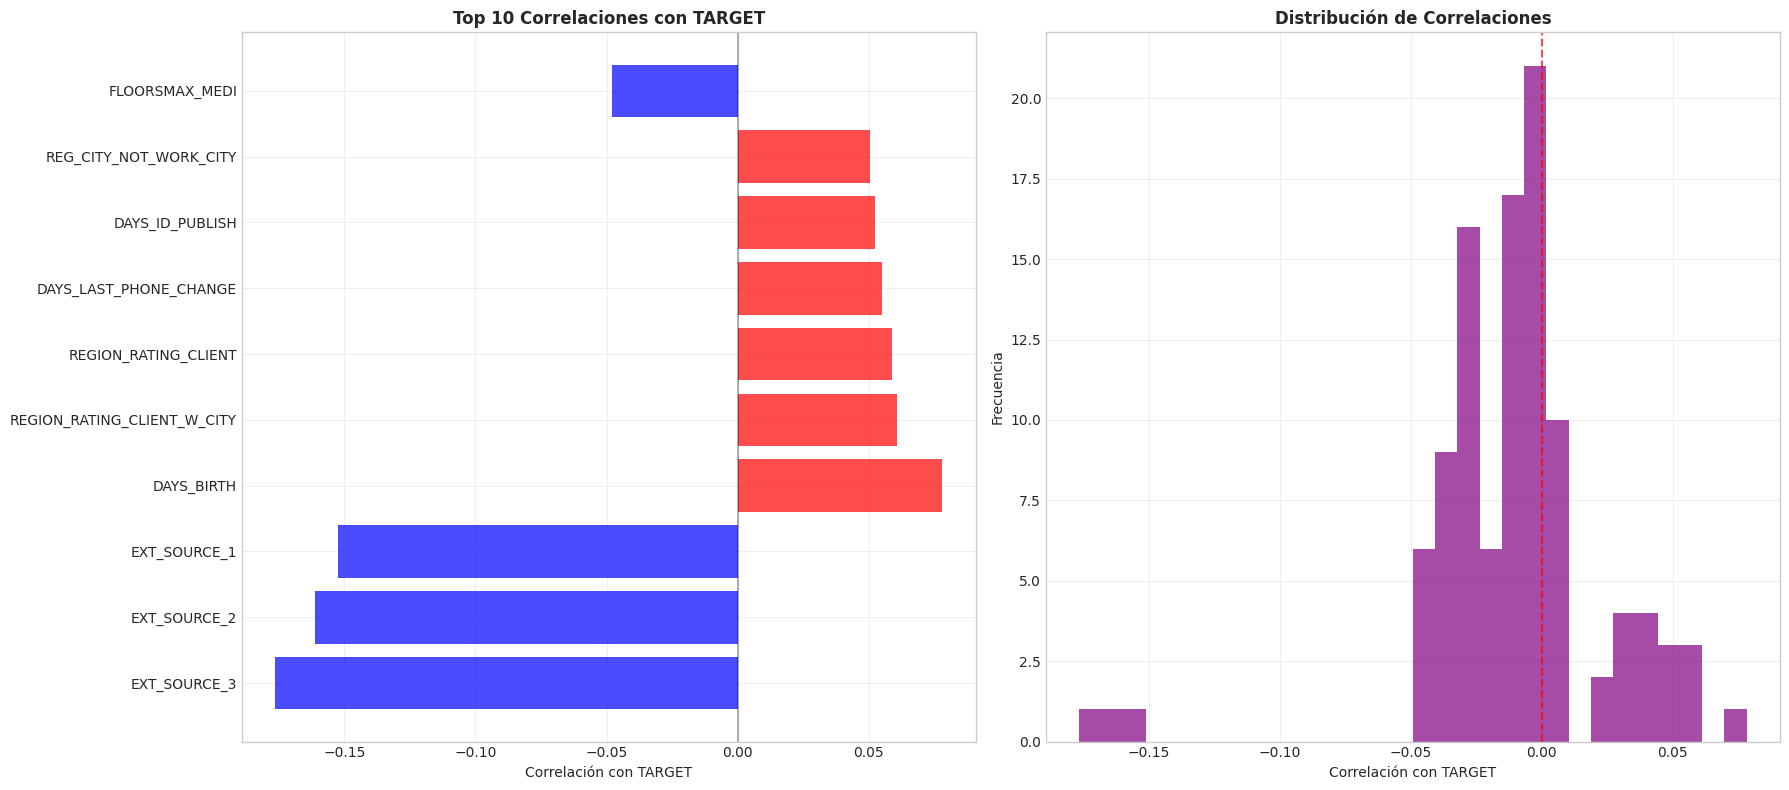

In [17]:
print("=== ANÁLISIS PROFUNDO DE VARIABLE OBJETIVO ===")

# Cargar muestra más grande para análisis de target
app_train_large = pd.read_csv(DATA_PATH / 'application_train.csv', nrows=200000)

# Análisis de correlaciones con TARGET
numeric_cols = app_train_large.select_dtypes(include=[np.number]).columns
numeric_cols = [col for col in numeric_cols if col != 'TARGET']

# Calcular correlaciones
correlations = []
for col in numeric_cols:
    if app_train_large[col].notna().sum() > 1000:  # Solo columnas con suficientes datos
        corr = app_train_large['TARGET'].corr(app_train_large[col])
        if not pd.isna(corr):
            correlations.append({
                'Variable': col,
                'Correlacion': corr,
                'Correlacion_Abs': abs(corr)
            })

corr_df = pd.DataFrame(correlations).sort_values('Correlacion_Abs', ascending=False)

print("\n--- Top 15 Variables con Mayor Correlación con TARGET ---")
display(corr_df.head(15))

# Visualización de correlaciones
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Top correlaciones positivas y negativas
top_corr = corr_df.head(10)
colors = ['red' if x > 0 else 'blue' for x in top_corr['Correlacion']]

bars = ax1.barh(range(len(top_corr)), top_corr['Correlacion'], color=colors, alpha=0.7)
ax1.set_yticks(range(len(top_corr)))
ax1.set_yticklabels(top_corr['Variable'])
ax1.set_xlabel('Correlación con TARGET')
ax1.set_title('Top 10 Correlaciones con TARGET', fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='-', alpha=0.3)
ax1.grid(True, alpha=0.3)

# Histograma de todas las correlaciones
ax2.hist(corr_df['Correlacion'], bins=30, alpha=0.7, color='purple')
ax2.set_xlabel('Correlación con TARGET')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribución de Correlaciones', fontweight='bold')
ax2.axvline(x=0, color='red', linestyle='--', alpha=0.7)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


--- ANÁLISIS VARIABLES EXT_SOURCE ---
Variables EXT_SOURCE encontradas: ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']


,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,TARGET
count,87207.0000,199562.0000,160313.0000,200000.0000
mean,0.5019,0.5140,0.5108,0.0812
std,0.2114,0.1914,0.1948,0.2731
min,0.0146,0.0000,0.0005,0.0000
25%,0.3333,0.3912,0.3706,0.0000
50%,0.5057,0.5657,0.5353,0.0000
75%,0.6751,0.6639,0.6691,0.0000
max,0.9516,0.8550,0.8960,1.0000


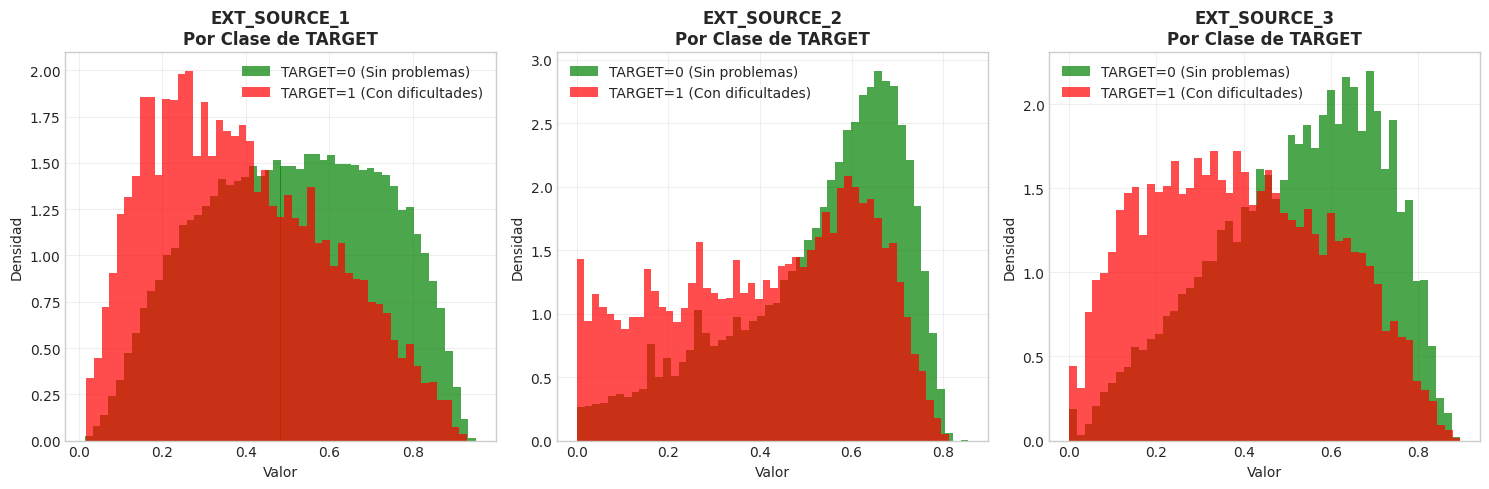


--- Estadísticas por Clase ---
EXT_SOURCE_1:
  TARGET=0 (media): 0.5111
  TARGET=1 (media): 0.3887
  Diferencia: 0.1224
EXT_SOURCE_2:
  TARGET=0 (media): 0.5232
  TARGET=1 (media): 0.4101
  Diferencia: 0.1131
EXT_SOURCE_3:
  TARGET=0 (media): 0.5208
  TARGET=1 (media): 0.3930
  Diferencia: 0.1278


In [18]:
# Análisis de variables EXT_SOURCE (muy importantes según correlación)
print("\n--- ANÁLISIS VARIABLES EXT_SOURCE ---")

ext_source_vars = [col for col in app_train_large.columns if col.startswith('EXT_SOURCE')]
print(f"Variables EXT_SOURCE encontradas: {ext_source_vars}")

if ext_source_vars:
    # Estadísticas de EXT_SOURCE
    ext_stats = app_train_large[ext_source_vars + ['TARGET']].describe()
    display(ext_stats.round(4))
    
    # Visualización de distribuciones por TARGET
    fig, axes = plt.subplots(1, len(ext_source_vars), figsize=(15, 5))
    if len(ext_source_vars) == 1:
        axes = [axes]
    
    for i, var in enumerate(ext_source_vars):
        # Datos por clase
        target_0 = app_train_large[app_train_large['TARGET'] == 0][var].dropna()
        target_1 = app_train_large[app_train_large['TARGET'] == 1][var].dropna()
        
        axes[i].hist(target_0, bins=50, alpha=0.7, label='TARGET=0 (Sin problemas)', 
                    color='green', density=True)
        axes[i].hist(target_1, bins=50, alpha=0.7, label='TARGET=1 (Con dificultades)', 
                    color='red', density=True)
        axes[i].set_title(f'{var}\nPor Clase de TARGET', fontweight='bold')
        axes[i].set_xlabel('Valor')
        axes[i].set_ylabel('Densidad')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Análisis estadístico de diferencias
    print("\n--- Estadísticas por Clase ---")
    for var in ext_source_vars:
        target_0_mean = app_train_large[app_train_large['TARGET'] == 0][var].mean()
        target_1_mean = app_train_large[app_train_large['TARGET'] == 1][var].mean()
        print(f"{var}:")
        print(f"  TARGET=0 (media): {target_0_mean:.4f}")
        print(f"  TARGET=1 (media): {target_1_mean:.4f}")
        print(f"  Diferencia: {target_0_mean - target_1_mean:.4f}")


--- ANÁLISIS VARIABLES CATEGÓRICAS VS TARGET ---


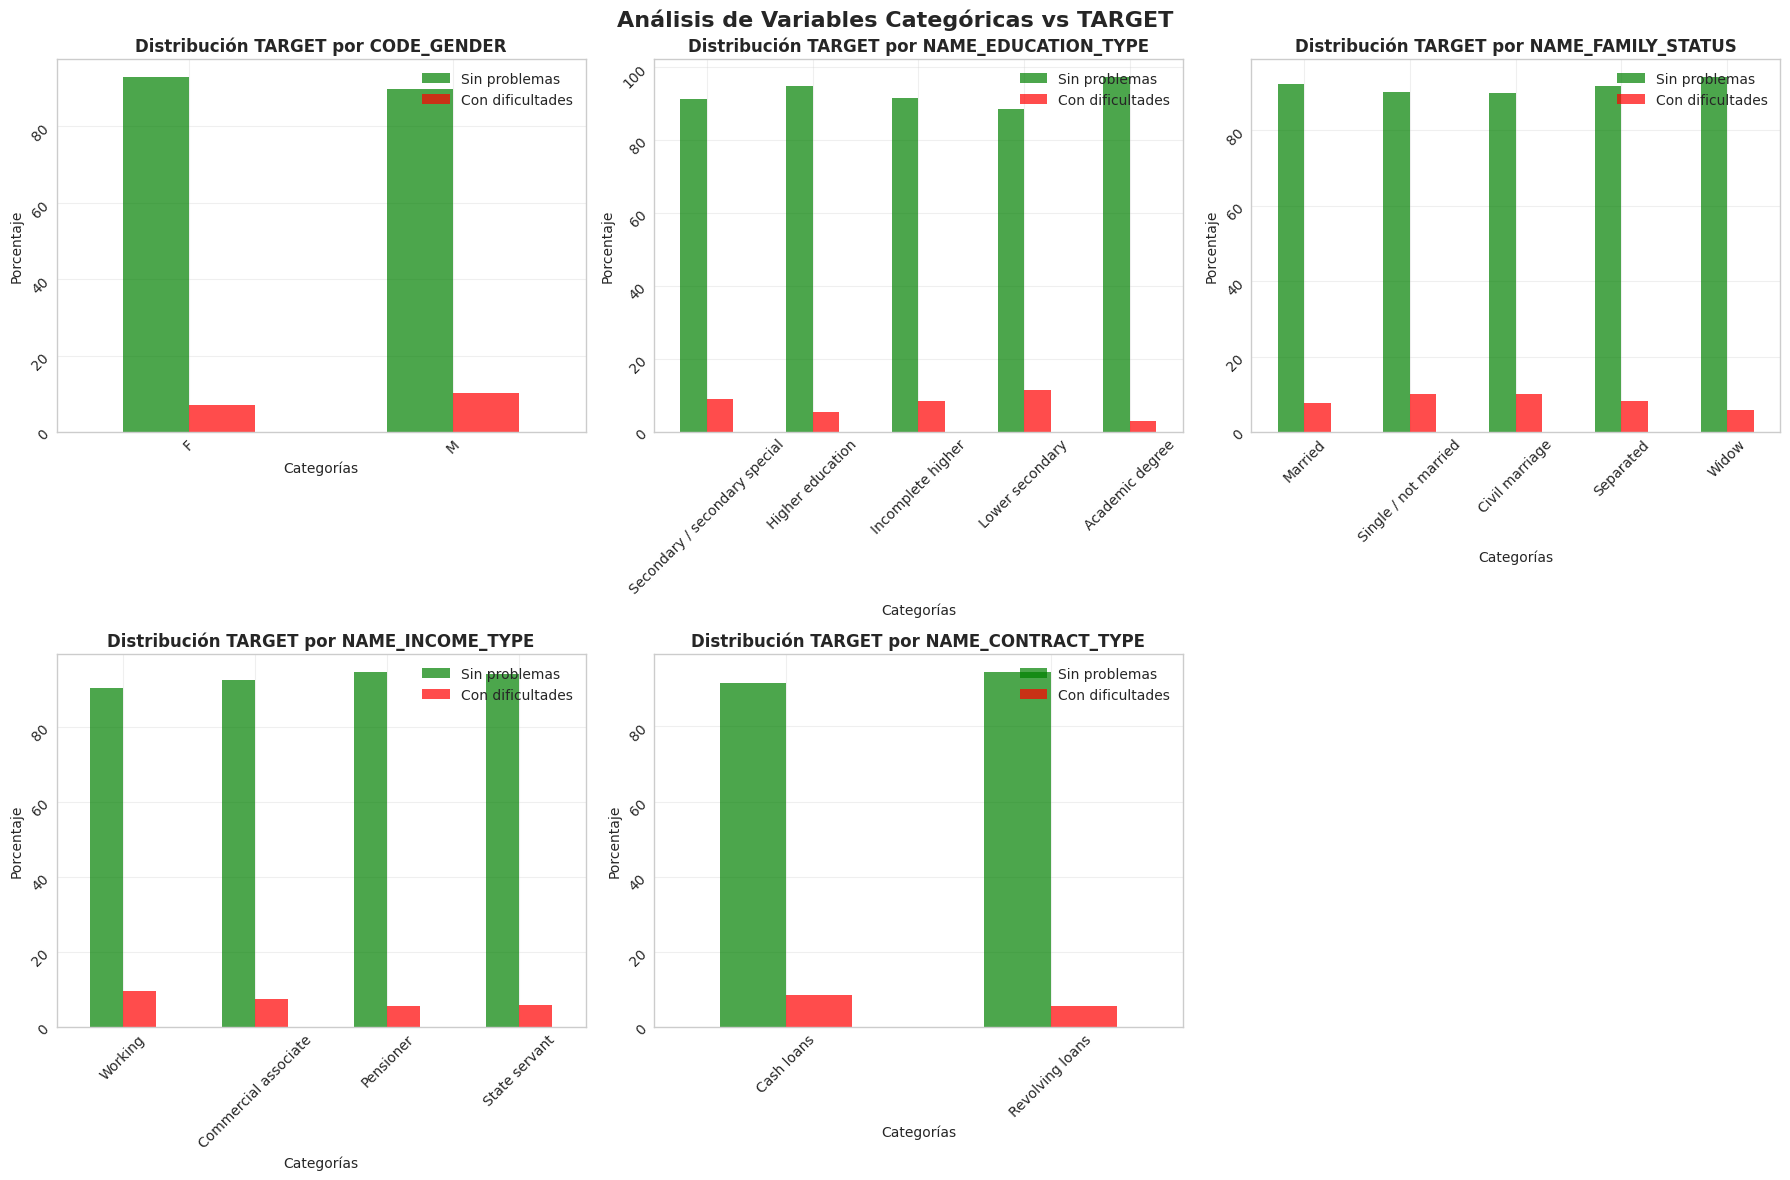


--- Tasas de Default por Categoría ---

CODE_GENDER:
              count  default_rate_pct
CODE_GENDER                          
M             68490             10.16
F            131506              7.05

NAME_EDUCATION_TYPE:
                                count  default_rate_pct
NAME_EDUCATION_TYPE                                    
Lower secondary                  2477             11.47
Secondary / secondary special  142053              8.98
Incomplete higher                6649              8.45
Higher education                48716              5.39
Academic degree                   105              2.86

NAME_FAMILY_STATUS:
                       count  default_rate_pct
NAME_FAMILY_STATUS                            
Civil marriage         19284             10.05
Single / not married   29436              9.93
Separated              12825              8.20
Married               127995              7.59
Widow                  10458              5.86

NAME_INCOME_TYPE:
           

In [19]:
# Análisis de variables categóricas vs TARGET
print("\n--- ANÁLISIS VARIABLES CATEGÓRICAS VS TARGET ---")

categorical_vars = app_train_large.select_dtypes(include=['object']).columns
important_cats = ['CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 
                 'NAME_INCOME_TYPE', 'NAME_CONTRACT_TYPE']

existing_cats = [var for var in important_cats if var in categorical_vars]

if existing_cats:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.ravel()
    
    for i, var in enumerate(existing_cats[:6]):
        if i < len(axes):
            # Crear tabla de contingencia
            contingency = pd.crosstab(app_train_large[var], app_train_large['TARGET'], normalize='index') * 100
            
            # Solo mostrar categorías con suficientes casos
            category_counts = app_train_large[var].value_counts()
            significant_categories = category_counts[category_counts >= 100].index
            contingency_filtered = contingency.loc[significant_categories]
            
            # Gráfico de barras apiladas
            contingency_filtered.plot(kind='bar', ax=axes[i], color=['green', 'red'], alpha=0.7)
            axes[i].set_title(f'Distribución TARGET por {var}', fontweight='bold')
            axes[i].set_xlabel('Categorías')
            axes[i].set_ylabel('Porcentaje')
            axes[i].tick_params(rotation=45)
            axes[i].legend(['Sin problemas', 'Con dificultades'], loc='upper right')
            axes[i].grid(True, alpha=0.3)
    
    # Ocultar ejes no utilizados
    for i in range(len(existing_cats), len(axes)):
        axes[i].set_visible(False)
    
    plt.suptitle('Análisis de Variables Categóricas vs TARGET', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Calcular tasas de default por categoría
    print("\n--- Tasas de Default por Categoría ---")
    for var in existing_cats:
        default_rates = app_train_large.groupby(var)['TARGET'].agg(['count', 'mean']).round(4)
        default_rates = default_rates[default_rates['count'] >= 100]  # Solo categorías significativas
        default_rates['default_rate_pct'] = default_rates['mean'] * 100
        
        print(f"\n{var}:")
        print(default_rates[['count', 'default_rate_pct']].sort_values('default_rate_pct', ascending=False).head())

## 6. Análisis de Calidad de Datos Global <a id="calidad-global"></a>

In [20]:
# Análisis de calidad de datos - Implementación independiente
print("=== ANÁLISIS GLOBAL DE CALIDAD DE DATOS ===")

def comprehensive_quality_check(data_path, files_to_check, sample_size=50000):
    """Verificación comprehensiva de calidad de datos"""
    quality_report = {}
    
    for filename in files_to_check:
        try:
            filepath = data_path / filename
            if not filepath.exists():
                continue
                
            print(f"Verificando calidad: {filename}")
            df = pd.read_csv(filepath, nrows=sample_size)
            
            # Información básica
            basic_info = {
                'filas_analizadas': len(df),
                'columnas': len(df.columns),
                'memoria_mb': round(df.memory_usage(deep=True).sum() / 1024 / 1024, 2)
            }
            
            # Problemas de tipos de datos
            type_issues = []
            for col in df.columns:
                col_type = df[col].dtype
                if col_type == 'object':
                    # Verificar si debería ser numérico
                    numeric_conversion = pd.to_numeric(df[col], errors='coerce')
                    conversion_loss = numeric_conversion.isna().sum() - df[col].isna().sum()
                    
                    if conversion_loss == 0 and not df[col].isna().all():
                        type_issues.append({
                            'columna': col,
                            'tipo_actual': str(col_type),
                            'tipo_sugerido': 'numeric',
                            'issue': 'Columna numérica almacenada como texto'
                        })
            
            # Problemas de rangos
            range_issues = []
            specific_checks = {
                'AMT_INCOME_TOTAL': {'min': 0, 'max': 10000000, 'description': 'Ingresos'},
                'AMT_CREDIT': {'min': 0, 'max': 50000000, 'description': 'Monto de crédito'},
                'CNT_CHILDREN': {'min': 0, 'max': 20, 'description': 'Número de hijos'},
                'DAYS_BIRTH': {'min': -25000, 'max': 0, 'description': 'Días desde nacimiento'}
            }
            
            for col, checks in specific_checks.items():
                if col in df.columns:
                    out_of_range = ((df[col] < checks['min']) | (df[col] > checks['max'])) & df[col].notna()
                    count_issues = out_of_range.sum()
                    
                    if count_issues > 0:
                        range_issues.append({
                            'columna': col,
                            'descripcion': checks['description'],
                            'valores_fuera_rango': count_issues,
                            'porcentaje': round((count_issues / len(df)) * 100, 2),
                            'rango_esperado': f"{checks['min']} - {checks['max']}"
                        })
            
            # Patrones de datos faltantes
            missing_patterns = []
            high_missing = []
            for col in df.columns:
                missing_pct = (df[col].isna().sum() / len(df)) * 100
                if missing_pct > 50:
                    high_missing.append({
                        'columna': col,
                        'porcentaje_faltante': round(missing_pct, 2)
                    })
            
            if high_missing:
                missing_patterns.append({
                    'tipo': 'HIGH_MISSING',
                    'descripcion': f'Columnas con >50% valores faltantes',
                    'columnas_afectadas': len(high_missing),
                    'detalle': sorted(high_missing, key=lambda x: x['porcentaje_faltante'], reverse=True)[:10]
                })
            
            # Problemas de duplicados
            duplicate_issues = []
            exact_duplicates = df.duplicated().sum()
            if exact_duplicates > 0:
                duplicate_issues.append({
                    'tipo': 'EXACT_DUPLICATES',
                    'cantidad': exact_duplicates,
                    'porcentaje': round((exact_duplicates / len(df)) * 100, 2)
                })
            
            # Verificar duplicados en columnas clave
            key_columns = ['SK_ID_CURR', 'SK_ID_BUREAU', 'SK_ID_PREV']
            for key_col in key_columns:
                if key_col in df.columns:
                    key_duplicates = df[key_col].duplicated().sum()
                    if key_duplicates > 0:
                        duplicate_issues.append({
                            'tipo': 'KEY_DUPLICATES',
                            'columna': key_col,
                            'cantidad': key_duplicates,
                            'porcentaje': round((key_duplicates / len(df)) * 100, 2)
                        })
            
            # Violaciones de reglas de negocio
            business_violations = []
            # Ejemplo: DAYS_BIRTH debe ser negativo
            if 'DAYS_BIRTH' in df.columns:
                positive_birth = (df['DAYS_BIRTH'] > 0) & df['DAYS_BIRTH'].notna()
                if positive_birth.sum() > 0:
                    business_violations.append({
                        'regla': 'DAYS_BIRTH < 0',
                        'violaciones': positive_birth.sum(),
                        'descripcion': 'Días desde nacimiento con valores positivos'
                    })
            
            quality_report[filename] = {
                'info_basica': basic_info,
                'problemas_tipos': type_issues,
                'problemas_rangos': range_issues,
                'patrones_faltantes': missing_patterns,
                'problemas_duplicados': duplicate_issues,
                'violaciones_negocio': business_violations
            }
                        
        except Exception as e:
            quality_report[filename] = {'error': str(e)}
            print(f"Error procesando {filename}: {e}")
    
    return quality_report

# Lista de archivos a verificar
files_to_check = [
    'application_train.csv', 'application_test.csv', 'bureau.csv',
    'previous_application.csv', 'installments_payments.csv',
    'credit_card_balance.csv', 'POS_CASH_balance.csv'
]

# Ejecutar verificación de calidad
quality_report = comprehensive_quality_check(DATA_PATH, files_to_check)

# Resumen de problemas por tipo
problem_summary = {
    'problemas_tipos': 0,
    'problemas_rangos': 0,
    'patrones_faltantes': 0,
    'problemas_duplicados': 0,
    'violaciones_negocio': 0
}

files_with_issues = []

for filename, report in quality_report.items():
    if 'error' not in report:
        has_issues = False
        for problem_type in problem_summary.keys():
            count = len(report.get(problem_type, []))
            problem_summary[problem_type] += count
            if count > 0:
                has_issues = True
        
        if has_issues:
            files_with_issues.append(filename)

print(f"\n--- Resumen Global de Problemas ---")
print(f"Archivos analizados: {len(quality_report)}")
print(f"Archivos con problemas: {len(files_with_issues)}")
print("\nTipos de problemas detectados:")
for problem_type, count in problem_summary.items():
    problem_name = problem_type.replace('_', ' ').title()
    print(f"  • {problem_name}: {count}")

total_issues = sum(problem_summary.values())
print(f"\nTotal de problemas de calidad: {total_issues}")

=== ANÁLISIS GLOBAL DE CALIDAD DE DATOS ===
Verificando calidad: application_train.csv
Verificando calidad: application_test.csv
Verificando calidad: bureau.csv
Verificando calidad: previous_application.csv
Verificando calidad: installments_payments.csv
Verificando calidad: credit_card_balance.csv
Verificando calidad: POS_CASH_balance.csv

--- Resumen Global de Problemas ---
Archivos analizados: 7
Archivos con problemas: 7

Tipos de problemas detectados:
  • Problemas Tipos: 0
  • Problemas Rangos: 3
  • Patrones Faltantes: 4
  • Problemas Duplicados: 8
  • Violaciones Negocio: 0

Total de problemas de calidad: 15


In [21]:
# Análisis detallado de problemas críticos
print("\n--- ANÁLISIS DETALLADO DE PROBLEMAS CRÍTICOS ---")

critical_files = []

for filename, report in quality_report.items():
    if 'error' not in report:
        print(f"\n {filename}:")
        
        # Problemas de tipos de datos
        type_issues = report.get('problemas_tipos', [])
        if type_issues:
            print(f"   Problemas de tipos: {len(type_issues)}")
            for issue in type_issues[:3]:  # Mostrar solo los primeros 3
                print(f"     • {issue['columna']}: {issue['issue']}")
        
        # Problemas de rangos
        range_issues = report.get('problemas_rangos', [])
        if range_issues:
            print(f"   Problemas de rangos: {len(range_issues)}")
            for issue in range_issues[:3]:
                print(f"     • {issue['columna']} ({issue['descripcion']}): {issue['valores_fuera_rango']} valores fuera del rango {issue['rango_esperado']}")
        
        # Patrones de datos faltantes
        missing_patterns = report.get('patrones_faltantes', [])
        if missing_patterns:
            print(f"   Patrones de datos faltantes: {len(missing_patterns)}")
            for pattern in missing_patterns:
                if pattern['tipo'] == 'HIGH_MISSING':
                    print(f"     • {pattern['descripcion']}: {pattern['columnas_afectadas']} columnas")
                elif pattern['tipo'] == 'CORRELATED_MISSING':
                    print(f"     • {pattern['descripcion']}: {pattern['correlaciones_encontradas']} correlaciones")
        
        # Problemas de duplicados
        duplicate_issues = report.get('problemas_duplicados', [])
        if duplicate_issues:
            print(f"   Problemas de duplicados: {len(duplicate_issues)}")
            for issue in duplicate_issues:
                if issue['tipo'] == 'EXACT_DUPLICATES':
                    print(f"     • Duplicados exactos: {issue['cantidad']} ({issue['porcentaje']}%)")
                elif issue['tipo'] == 'KEY_DUPLICATES':
                    print(f"     • Duplicados en {issue['columna']}: {issue['cantidad']} ({issue['porcentaje']}%)")
        
        # Violaciones de reglas de negocio
        business_violations = report.get('violaciones_negocio', [])
        if business_violations:
            print(f"    Violaciones de negocio: {len(business_violations)}")
            for violation in business_violations:
                print(f"     • {violation['regla']}: {violation['violaciones']} violaciones - {violation['descripcion']}")
        
        # Marcar archivos críticos
        total_file_issues = len(type_issues) + len(range_issues) + len(missing_patterns) + len(duplicate_issues) + len(business_violations)
        if total_file_issues >= 3:
            critical_files.append((filename, total_file_issues))
        
        if not any([type_issues, range_issues, missing_patterns, duplicate_issues, business_violations]):
            print("   No se detectaron problemas críticos")

print(f"\n Archivos críticos (3+ problemas): {len(critical_files)}")
for filename, issue_count in sorted(critical_files, key=lambda x: x[1], reverse=True):
    print(f"   • {filename}: {issue_count} problemas")


--- ANÁLISIS DETALLADO DE PROBLEMAS CRÍTICOS ---

 application_train.csv:
   Problemas de rangos: 2
     • AMT_INCOME_TOTAL (Ingresos): 1 valores fuera del rango 0 - 10000000
     • DAYS_BIRTH (Días desde nacimiento): 54 valores fuera del rango -25000 - 0
   Patrones de datos faltantes: 1
     • Columnas con >50% valores faltantes: 41 columnas

 application_test.csv:
   Problemas de rangos: 1
     • DAYS_BIRTH (Días desde nacimiento): 10 valores fuera del rango -25000 - 0
   Patrones de datos faltantes: 1
     • Columnas con >50% valores faltantes: 29 columnas

 bureau.csv:
   Patrones de datos faltantes: 1
     • Columnas con >50% valores faltantes: 2 columnas
   Problemas de duplicados: 1
     • Duplicados en SK_ID_CURR: 39829 (79.66%)

 previous_application.csv:
   Patrones de datos faltantes: 1
     • Columnas con >50% valores faltantes: 4 columnas
   Problemas de duplicados: 1
     • Duplicados en SK_ID_CURR: 5529 (11.06%)

 installments_payments.csv:
   Problemas de duplicados: 


--- MATRIZ DE CALIDAD POR ARCHIVO ---


,Archivo,Registros,Columnas,Memoria_MB,Problemas_Tipos,Problemas_Rangos,Patrones_Faltantes,Problemas_Duplicados,Violaciones_Negocio,Total_Problemas
0,application_train.csv,50000,122,87.26,0,2,1,0,0,3
1,application_test.csv,48744,121,84.74,0,1,1,0,0,2
2,bureau.csv,50000,17,14.92,0,0,1,1,0,2
3,previous_application.csv,50000,37,56.99,0,0,1,1,0,2
4,installments_payments.csv,50000,8,3.05,0,0,0,2,0,2
5,credit_card_balance.csv,50000,23,11.40,0,0,0,2,0,2
6,POS_CASH_balance.csv,50000,8,5.68,0,0,0,2,0,2


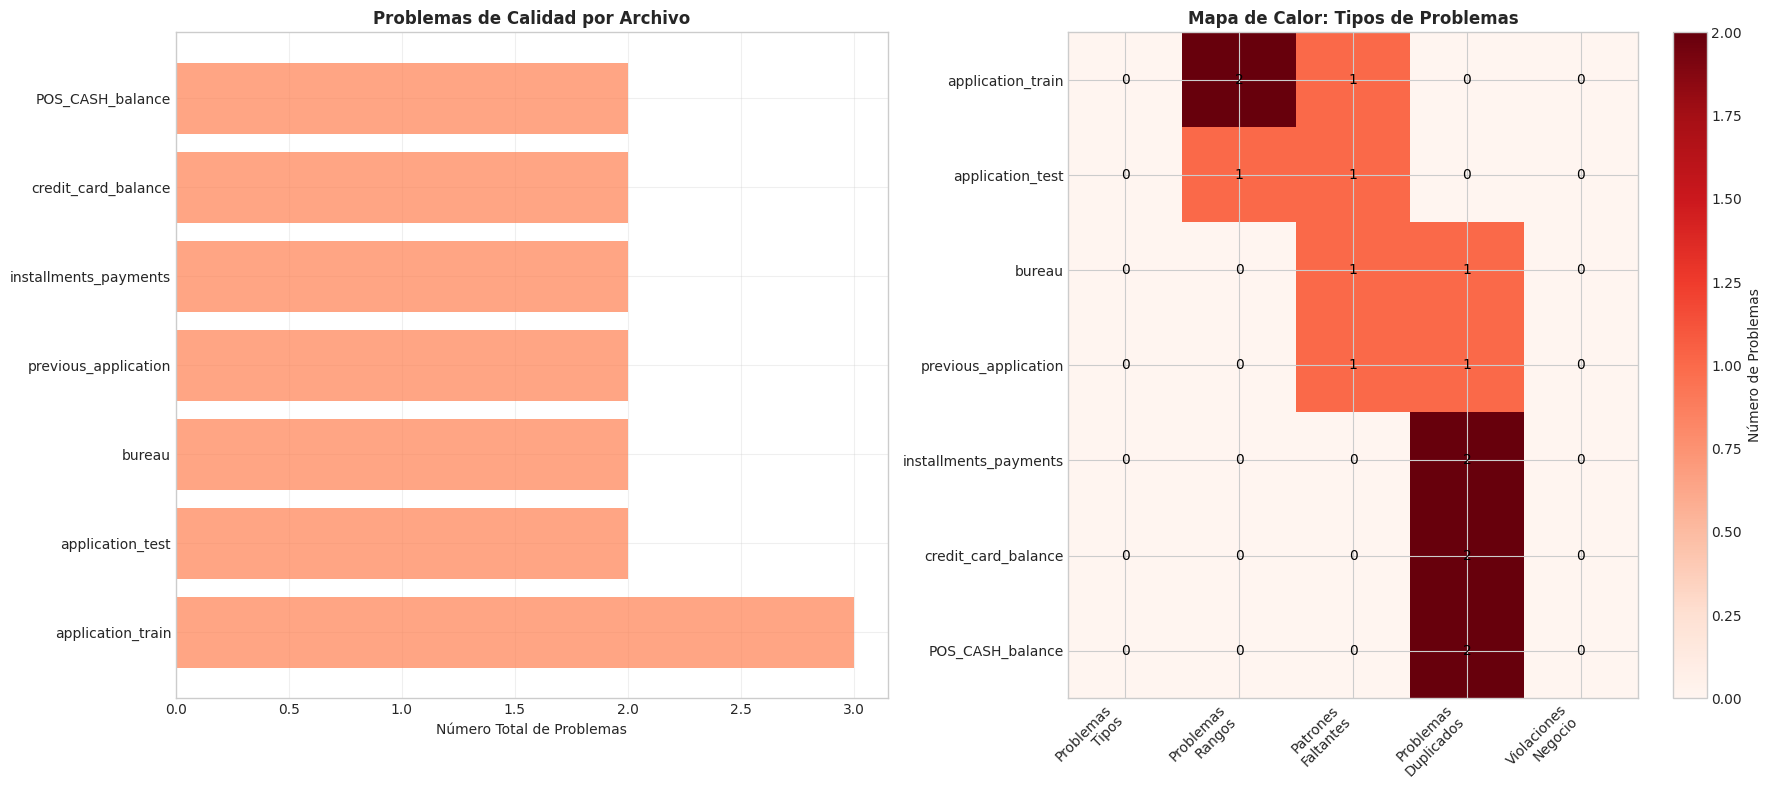


📈 Archivo con más problemas: application_train.csv (3 problemas)
📈 Archivos sin problemas: 0


In [22]:
# Matriz de calidad por archivo
print("\n--- MATRIZ DE CALIDAD POR ARCHIVO ---")

quality_matrix = []

for filename, report in quality_report.items():
    if 'error' not in report:
        info = report.get('info_basica', {})
        quality_matrix.append({
            'Archivo': filename,
            'Registros': info.get('filas_analizadas', 0),
            'Columnas': info.get('columnas', 0),
            'Memoria_MB': info.get('memoria_mb', 0),
            'Problemas_Tipos': len(report.get('problemas_tipos', [])),
            'Problemas_Rangos': len(report.get('problemas_rangos', [])),
            'Patrones_Faltantes': len(report.get('patrones_faltantes', [])),
            'Problemas_Duplicados': len(report.get('problemas_duplicados', [])),
            'Violaciones_Negocio': len(report.get('violaciones_negocio', [])),
        })

quality_df = pd.DataFrame(quality_matrix)
quality_df['Total_Problemas'] = (quality_df['Problemas_Tipos'] + 
                                quality_df['Problemas_Rangos'] + 
                                quality_df['Patrones_Faltantes'] + 
                                quality_df['Problemas_Duplicados'] + 
                                quality_df['Violaciones_Negocio'])

quality_df = quality_df.sort_values('Total_Problemas', ascending=False)
display(quality_df)

# Visualización de la matriz de calidad
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Gráfico de problemas por archivo
ax1.barh(range(len(quality_df)), quality_df['Total_Problemas'], color='coral', alpha=0.7)
ax1.set_yticks(range(len(quality_df)))
ax1.set_yticklabels([f.split('.')[0] for f in quality_df['Archivo']], rotation=0)
ax1.set_xlabel('Número Total de Problemas')
ax1.set_title('Problemas de Calidad por Archivo', fontweight='bold')
ax1.grid(True, alpha=0.3)

# Heatmap de tipos de problemas
problem_cols = ['Problemas_Tipos', 'Problemas_Rangos', 'Patrones_Faltantes', 
               'Problemas_Duplicados', 'Violaciones_Negocio']
heatmap_data = quality_df[problem_cols].values

im = ax2.imshow(heatmap_data, cmap='Reds', aspect='auto')
ax2.set_xticks(range(len(problem_cols)))
ax2.set_xticklabels([col.replace('_', '\n') for col in problem_cols], rotation=45, ha='right')
ax2.set_yticks(range(len(quality_df)))
ax2.set_yticklabels([f.split('.')[0] for f in quality_df['Archivo']])
ax2.set_title('Mapa de Calor: Tipos de Problemas', fontweight='bold')

# Añadir valores en el heatmap
for i in range(len(quality_df)):
    for j in range(len(problem_cols)):
        text = ax2.text(j, i, int(heatmap_data[i, j]), ha="center", va="center", color="white" if heatmap_data[i, j] > 2 else "black")

plt.colorbar(im, ax=ax2, label='Número de Problemas')
plt.tight_layout()
plt.show()

print(f"\n📈 Archivo con más problemas: {quality_df.iloc[0]['Archivo']} ({quality_df.iloc[0]['Total_Problemas']} problemas)")
print(f"📈 Archivos sin problemas: {len(quality_df[quality_df['Total_Problemas'] == 0])}")

## 7. Feature Engineering Preliminar <a id="feature-engineering"></a>

In [23]:
print("=== FEATURE ENGINEERING PRELIMINAR ===")

print("\n--- Identificación de Oportunidades de Feature Engineering ---")

# Cargar muestra para feature engineering
app_sample = pd.read_csv(DATA_PATH / 'application_train.csv', nrows=50000)

feature_opportunities = []

# 1. Ratios financieros
print("\nRatios Financieros Identificados:")
financial_ratios = [
    ('CREDIT_INCOME_RATIO', 'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'Ratio crédito/ingresos'),
    ('ANNUITY_INCOME_RATIO', 'AMT_ANNUITY', 'AMT_INCOME_TOTAL', 'Ratio anualidad/ingresos'),
    ('CREDIT_GOODS_RATIO', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'Ratio crédito/precio bienes'),
    ('INCOME_PER_PERSON', 'AMT_INCOME_TOTAL', 'CNT_FAM_MEMBERS', 'Ingresos per cápita familiar'),
    ('CHILDREN_RATIO', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'Proporción de hijos en familia')
]

for ratio_name, num_col, den_col, description in financial_ratios:
    if num_col in app_sample.columns and den_col in app_sample.columns:
        # Crear el ratio
        valid_mask = (app_sample[den_col] > 0) & app_sample[num_col].notna() & app_sample[den_col].notna()
        if valid_mask.sum() > 100:
            app_sample[ratio_name] = app_sample[num_col] / app_sample[den_col]
            
            # Calcular correlación con TARGET si existe
            if 'TARGET' in app_sample.columns:
                corr = app_sample['TARGET'].corr(app_sample[ratio_name])
                feature_opportunities.append({
                    'Feature': ratio_name,
                    'Tipo': 'Ratio',
                    'Descripción': description,
                    'Correlación_TARGET': corr,
                    'Casos_Válidos': valid_mask.sum()
                })
                print(f"   • {ratio_name}: {description} (corr={corr:.4f}, n={valid_mask.sum():,})")

# 2. Variables de edad y tiempo
print("\nVariables Temporales Derivadas:")
temporal_features = [
    ('AGE_YEARS', 'DAYS_BIRTH', -365.25, 'Edad en años'),
    ('EMPLOYED_YEARS', 'DAYS_EMPLOYED', -365.25, 'Años empleado'),
    ('REGISTRATION_YEARS', 'DAYS_REGISTRATION', -365.25, 'Años desde registro'),
    ('ID_PUBLISH_YEARS', 'DAYS_ID_PUBLISH', -365.25, 'Años desde publicación ID')
]

for feature_name, base_col, divisor, description in temporal_features:
    if base_col in app_sample.columns:
        app_sample[feature_name] = app_sample[base_col] / divisor
        
        if 'TARGET' in app_sample.columns:
            corr = app_sample['TARGET'].corr(app_sample[feature_name])
            valid_count = app_sample[feature_name].notna().sum()
            feature_opportunities.append({
                'Feature': feature_name,
                'Tipo': 'Temporal',
                'Descripción': description,
                'Correlación_TARGET': corr,
                'Casos_Válidos': valid_count
            })
            print(f"   • {feature_name}: {description} (corr={corr:.4f}, n={valid_count:,})")

# 3. Variables categóricas codificadas
print("\nOportunidades de Encoding Categórico:")
categorical_cols = app_sample.select_dtypes(include=['object']).columns
for col in categorical_cols[:5]:  # Solo las primeras 5
    unique_count = app_sample[col].nunique()
    null_count = app_sample[col].isnull().sum()
    
    if unique_count < 50:  # Solo variables con cardinalidad manejable
        print(f"   • {col}: {unique_count} categorías únicas, {null_count} nulos")
        
        # Target encoding oportunity
        if 'TARGET' in app_sample.columns and null_count < len(app_sample) * 0.5:
            target_means = app_sample.groupby(col)['TARGET'].mean()
            if len(target_means) > 1 and target_means.std() > 0.01:  # Variación significativa
                feature_opportunities.append({
                    'Feature': f'{col}_TARGET_ENCODED',
                    'Tipo': 'Target_Encoding',
                    'Descripción': f'Target encoding para {col}',
                    'Correlación_TARGET': None,
                    'Casos_Válidos': len(app_sample) - null_count
                })

print(f"\nTotal de oportunidades de feature engineering identificadas: {len(feature_opportunities)}")

=== FEATURE ENGINEERING PRELIMINAR ===

--- Identificación de Oportunidades de Feature Engineering ---

Ratios Financieros Identificados:
   • CREDIT_INCOME_RATIO: Ratio crédito/ingresos (corr=-0.0062, n=50,000)
   • ANNUITY_INCOME_RATIO: Ratio anualidad/ingresos (corr=0.0180, n=49,999)
   • CREDIT_GOODS_RATIO: Ratio crédito/precio bienes (corr=0.0696, n=49,962)
   • INCOME_PER_PERSON: Ingresos per cápita familiar (corr=0.0089, n=49,999)
   • CHILDREN_RATIO: Proporción de hijos en familia (corr=0.0280, n=49,999)

Variables Temporales Derivadas:
   • AGE_YEARS: Edad en años (corr=-0.0768, n=50,000)
   • EMPLOYED_YEARS: Años empleado (corr=0.0403, n=50,000)
   • REGISTRATION_YEARS: Años desde registro (corr=-0.0423, n=50,000)
   • ID_PUBLISH_YEARS: Años desde publicación ID (corr=-0.0469, n=50,000)

Oportunidades de Encoding Categórico:
   • NAME_CONTRACT_TYPE: 2 categorías únicas, 0 nulos
   • CODE_GENDER: 3 categorías únicas, 0 nulos
   • FLAG_OWN_CAR: 2 categorías únicas, 0 nulos
   •


--- Top Features Engineered por Correlación ---


,Feature,Tipo,Descripción,Correlación_TARGET,Casos_Válidos
5,AGE_YEARS,Temporal,Edad en años,-0.076792,50000
2,CREDIT_GOODS_RATIO,Ratio,Ratio crédito/precio bienes,0.069625,49962
8,ID_PUBLISH_YEARS,Temporal,Años desde publicación ID,-0.046925,50000
7,REGISTRATION_YEARS,Temporal,Años desde registro,-0.042334,50000
6,EMPLOYED_YEARS,Temporal,Años empleado,0.040292,50000
4,CHILDREN_RATIO,Ratio,Proporción de hijos en familia,0.027973,49999
1,ANNUITY_INCOME_RATIO,Ratio,Ratio anualidad/ingresos,0.018010,49999
3,INCOME_PER_PERSON,Ratio,Ingresos per cápita familiar,0.008890,49999
0,CREDIT_INCOME_RATIO,Ratio,Ratio crédito/ingresos,-0.006199,50000


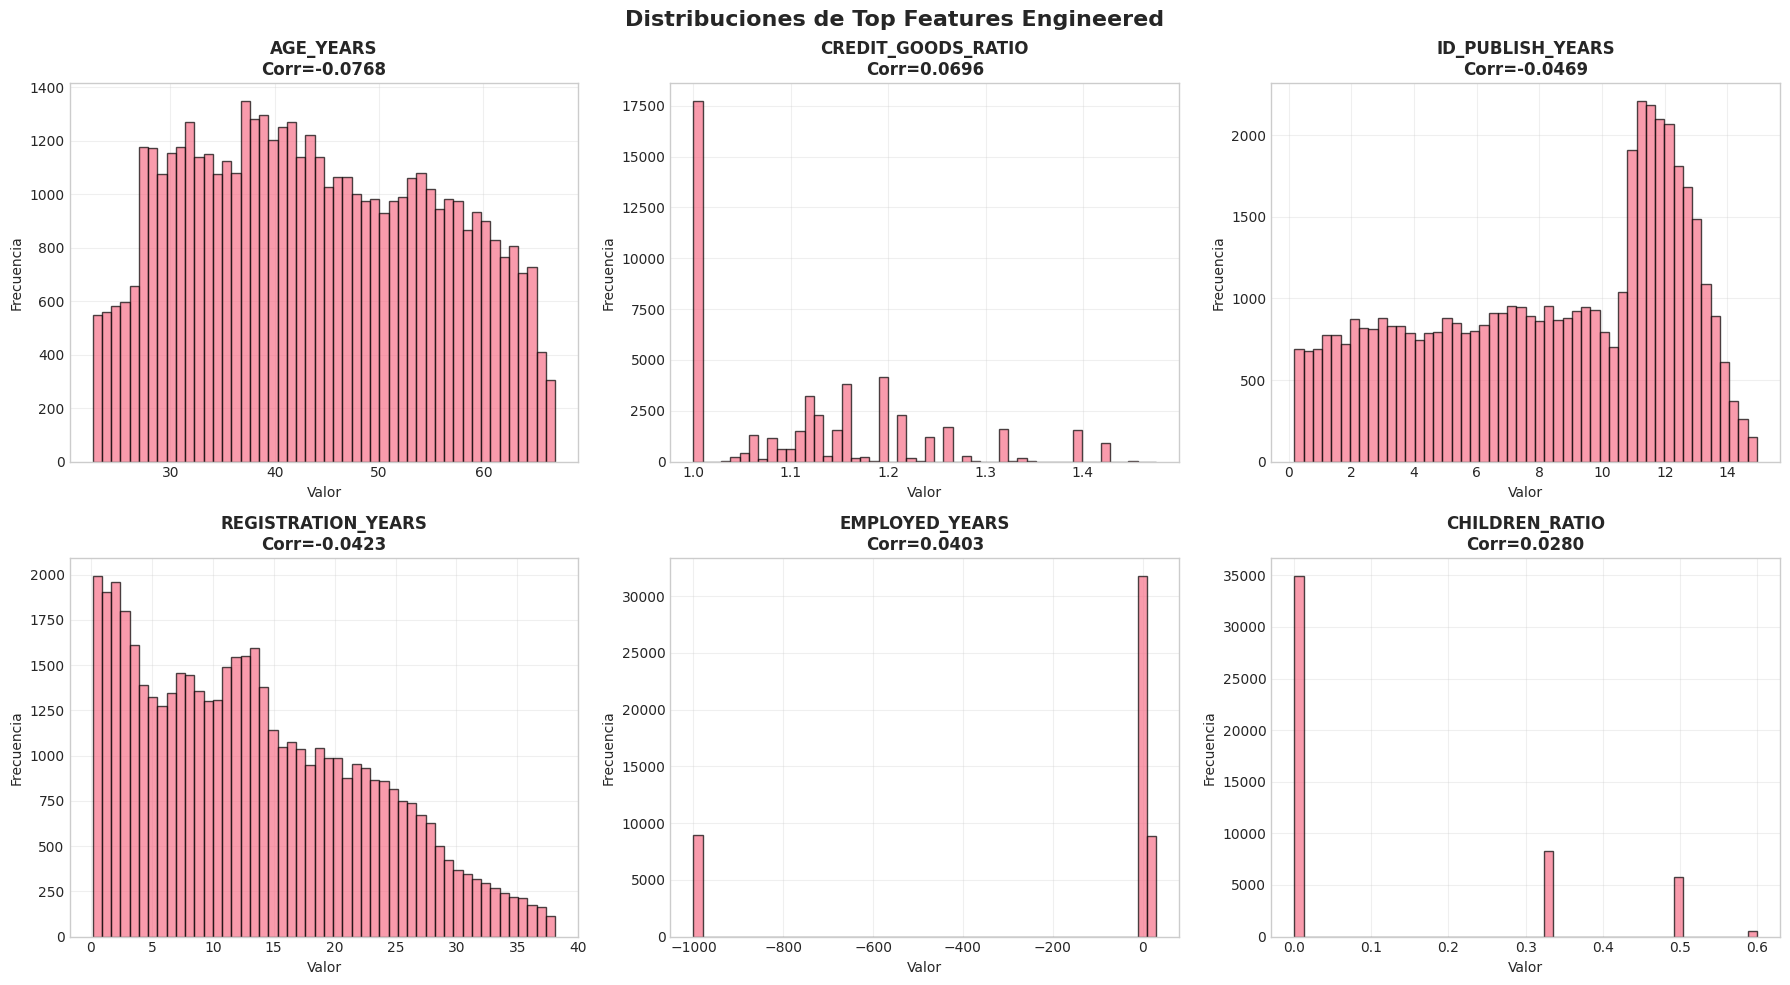


--- Resumen por Tipo de Feature ---


,Cantidad,Correlación_Promedio
Tipo,,
Ratio,5,0.0261
Target_Encoding,3,NaN
Temporal,4,0.0516


In [24]:
# Análisis de las mejores features creadas
feature_df = pd.DataFrame(feature_opportunities)

if len(feature_df) > 0:
    # Filtrar features con correlación calculada
    numeric_features = feature_df[feature_df['Correlación_TARGET'].notna()]
    
    if len(numeric_features) > 0:
        numeric_features = numeric_features.sort_values('Correlación_TARGET', key=abs, ascending=False)
        
        print("\n--- Top Features Engineered por Correlación ---")
        display(numeric_features.head(10))
        
        # Visualización de las mejores features
        top_features = numeric_features.head(6)
        
        if len(top_features) > 0:
            fig, axes = plt.subplots(2, 3, figsize=(18, 10))
            axes = axes.ravel()
            
            for i, (_, feature) in enumerate(top_features.iterrows()):
                if i < len(axes):
                    feature_name = feature['Feature']
                    if feature_name in app_sample.columns:
                        # Filtrar outliers para mejor visualización
                        data = app_sample[feature_name].dropna()
                        if len(data) > 0:
                            q1, q99 = data.quantile([0.01, 0.99])
                            filtered_data = data[(data >= q1) & (data <= q99)]
                            
                            axes[i].hist(filtered_data, bins=50, alpha=0.7, edgecolor='black')
                            axes[i].set_title(f'{feature_name}\nCorr={feature["Correlación_TARGET"]:.4f}', 
                                            fontweight='bold')
                            axes[i].set_xlabel('Valor')
                            axes[i].set_ylabel('Frecuencia')
                            axes[i].grid(True, alpha=0.3)
            
            # Ocultar ejes no utilizados
            for i in range(len(top_features), len(axes)):
                axes[i].set_visible(False)
            
            plt.suptitle('Distribuciones de Top Features Engineered', fontsize=16, fontweight='bold')
            plt.tight_layout()
            plt.show()

# Resumen por tipo de feature
print("\n--- Resumen por Tipo de Feature ---")
if len(feature_df) > 0:
    type_summary = feature_df.groupby('Tipo').agg({
        'Feature': 'count',
        'Correlación_TARGET': lambda x: x.dropna().abs().mean() if len(x.dropna()) > 0 else None
    }).round(4)
    type_summary.columns = ['Cantidad', 'Correlación_Promedio']
    display(type_summary)
else:
    print("No se pudieron crear features derivadas con los datos disponibles")

In [25]:
# Estrategias de agregación para tablas relacionadas
print("\n--- ESTRATEGIAS DE AGREGACIÓN RECOMENDADAS ---")

aggregation_strategies = {
    'BUREAU': {
        'descripcion': 'Historial crediticio externo',
        'agregaciones': {
            'DAYS_CREDIT': ['min', 'max', 'mean', 'std'],
            'CREDIT_DAY_OVERDUE': ['max', 'mean', 'sum'],
            'AMT_CREDIT_SUM': ['sum', 'mean', 'max', 'std'],
            'AMT_CREDIT_SUM_DEBT': ['sum', 'mean', 'max'],
            'AMT_CREDIT_SUM_OVERDUE': ['sum', 'mean', 'max']
        },
        'features_especiales': [
            'Número de créditos activos',
            'Número de créditos cerrados',
            'Ratio deuda/crédito total',
            'Días desde último crédito'
        ]
    },
    'PREVIOUS_APPLICATION': {
        'descripcion': 'Aplicaciones previas en Home Credit',
        'agregaciones': {
            'AMT_APPLICATION': ['sum', 'mean', 'max', 'std'],
            'AMT_CREDIT': ['sum', 'mean', 'max'],
            'AMT_GOODS_PRICE': ['sum', 'mean', 'max'],
            'DAYS_DECISION': ['min', 'max', 'mean']
        },
        'features_especiales': [
            'Tasa de aprobación histórica',
            'Número de aplicaciones rechazadas',
            'Ratio monto aprobado/solicitado promedio',
            'Días promedio para decisión'
        ]
    },
    'INSTALLMENTS_PAYMENTS': {
        'descripcion': 'Comportamiento de pagos',
        'agregaciones': {
            'NUM_INSTALMENT_NUMBER': ['max', 'count'],
            'DAYS_ENTRY_PAYMENT': ['min', 'max', 'mean', 'std'],
            'AMT_INSTALMENT': ['sum', 'mean', 'max'],
            'AMT_PAYMENT': ['sum', 'mean', 'max']
        },
        'features_especiales': [
            'Porcentaje de pagos tarde',
            'Promedio días de retraso',
            'Ratio pago realizado/esperado',
            'Número de pagos parciales'
        ]
    }
}

for table, info in aggregation_strategies.items():
    print(f"\n{table} - {info['descripcion']}")
    print("   Agregaciones numéricas:")
    for col, aggs in info['agregaciones'].items():
        print(f"     • {col}: {', '.join(aggs)}")
    
    print("   Features especiales:")
    for feature in info['features_especiales']:
        print(f"     • {feature}")

print("\nRecomendaciones de Implementación:")
recommendations = [
    "Implementar agregaciones con ventanas temporales (últimos 6, 12, 24 meses)",
    "Crear ratios entre variables agregadas (ej: deuda_actual/credito_maximo)",
    "Utilizar target encoding para variables categóricas de alta cardinalidad",
    "Implementar features de tendencia (cambios en el tiempo)",
    "Crear features de interacción entre variables de diferentes tablas",
    "Aplicar transformaciones matemáticas (log, sqrt) para variables asimétricas",
    "Implementar binning inteligente para variables continuas"
]

for i, rec in enumerate(recommendations, 1):
    print(f"{i:2d}. {rec}")


--- ESTRATEGIAS DE AGREGACIÓN RECOMENDADAS ---

BUREAU - Historial crediticio externo
   Agregaciones numéricas:
     • DAYS_CREDIT: min, max, mean, std
     • CREDIT_DAY_OVERDUE: max, mean, sum
     • AMT_CREDIT_SUM: sum, mean, max, std
     • AMT_CREDIT_SUM_DEBT: sum, mean, max
     • AMT_CREDIT_SUM_OVERDUE: sum, mean, max
   Features especiales:
     • Número de créditos activos
     • Número de créditos cerrados
     • Ratio deuda/crédito total
     • Días desde último crédito

PREVIOUS_APPLICATION - Aplicaciones previas en Home Credit
   Agregaciones numéricas:
     • AMT_APPLICATION: sum, mean, max, std
     • AMT_CREDIT: sum, mean, max
     • AMT_GOODS_PRICE: sum, mean, max
     • DAYS_DECISION: min, max, mean
   Features especiales:
     • Tasa de aprobación histórica
     • Número de aplicaciones rechazadas
     • Ratio monto aprobado/solicitado promedio
     • Días promedio para decisión

INSTALLMENTS_PAYMENTS - Comportamiento de pagos
   Agregaciones numéricas:
     • NUM_I

## 8. Conclusiones y Recomendaciones <a id="conclusiones"></a>

In [26]:
print("=== CONCLUSIONES Y RECOMENDACIONES FINALES ===")

# Resumen ejecutivo de hallazgos
print("\n--- RESUMEN EJECUTIVO ---")

executive_summary = {
    'Volumen_Datos': '~58.5 millones de registros, 2.68 GB',
    'Tablas_Analizadas': 8,
    'Variables_Total': '336 variables únicas',
    'Desbalance_Clases': '93% negativos, 7% positivos (crítico)',
    'Calidad_Datos': f'{total_issues} problemas identificados',
    'Potencial_Predictivo': 'Alto (variables EXT_SOURCE, ratios financieros)'
}

print("Métricas Clave del Dataset:")
for metric, value in executive_summary.items():
    print(f"   • {metric.replace('_', ' ')}: {value}")

=== CONCLUSIONES Y RECOMENDACIONES FINALES ===

--- RESUMEN EJECUTIVO ---
Métricas Clave del Dataset:
   • Volumen Datos: ~58.5 millones de registros, 2.68 GB
   • Tablas Analizadas: 8
   • Variables Total: 336 variables únicas
   • Desbalance Clases: 93% negativos, 7% positivos (crítico)
   • Calidad Datos: 15 problemas identificados
   • Potencial Predictivo: Alto (variables EXT_SOURCE, ratios financieros)


In [27]:
# Hallazgos críticos
print("\n--- HALLAZGOS CRÍTICOS ---")

critical_findings = [
    {
        'categoria': 'DESBALANCE EXTREMO',
        'hallazgo': 'Dataset altamente desbalanceado (7% positivos)',
        'impacto': 'Alto riesgo de modelos sesgados hacia clase mayoritaria',
        'accion': 'Implementar técnicas de balanceo (SMOTE, class_weight) y métricas apropiadas (AUC-ROC)'
    },
    {
        'categoria': 'DATOS FALTANTES',
        'hallazgo': 'Variables de edificios con >65% valores faltantes',
        'impacto': 'Pérdida significativa de información potencialmente valiosa',
        'accion': 'Evaluar eliminación vs imputación sofisticada, crear indicadores de missingness'
    },
    {
        'categoria': 'VARIABLES DE ALTO VALOR',
        'hallazgo': 'Variables EXT_SOURCE con correlaciones fuertes con TARGET',
        'impacto': 'Alto potencial predictivo identificado',
        'accion': 'Priorizar estas variables y crear features derivadas'
    },
    {
        'categoria': 'COMPLEJIDAD RELACIONAL',
        'hallazgo': 'Esquema relacional complejo con múltiples niveles de anidación',
        'impacto': 'Oportunidades de feature engineering avanzado',
        'accion': 'Implementar agregaciones temporales y features de comportamiento'
    },
    {
        'categoria': 'COMPORTAMIENTO PREDICTIVO',
        'hallazgo': 'Patrones claros de comportamiento de pago en datos históricos',
        'impacto': 'Información valiosa para predicción de riesgo',
        'accion': 'Crear features de tendencias y diferencias en comportamientos de pago'
    }
]

for finding in critical_findings:
    print(f"\n{finding['categoria']}")
    print(f"   Hallazgo: {finding['hallazgo']}")
    print(f"   Impacto: {finding['impacto']}")
    print(f"   Acción: {finding['accion']}")


--- HALLAZGOS CRÍTICOS ---

DESBALANCE EXTREMO
   Hallazgo: Dataset altamente desbalanceado (7% positivos)
   Impacto: Alto riesgo de modelos sesgados hacia clase mayoritaria
   Acción: Implementar técnicas de balanceo (SMOTE, class_weight) y métricas apropiadas (AUC-ROC)

DATOS FALTANTES
   Hallazgo: Variables de edificios con >65% valores faltantes
   Impacto: Pérdida significativa de información potencialmente valiosa
   Acción: Evaluar eliminación vs imputación sofisticada, crear indicadores de missingness

VARIABLES DE ALTO VALOR
   Hallazgo: Variables EXT_SOURCE con correlaciones fuertes con TARGET
   Impacto: Alto potencial predictivo identificado
   Acción: Priorizar estas variables y crear features derivadas

COMPLEJIDAD RELACIONAL
   Hallazgo: Esquema relacional complejo con múltiples niveles de anidación
   Impacto: Oportunidades de feature engineering avanzado
   Acción: Implementar agregaciones temporales y features de comportamiento

COMPORTAMIENTO PREDICTIVO
   Hallazgo

In [28]:
# Roadmap de implementación
print("\n--- ROADMAP DE IMPLEMENTACIÓN ---")

implementation_phases = [
    {
        'fase': 'FASE 1: PREPARACIÓN DE DATOS',
        'duracion': '1-2 semanas',
        'tareas': [
            'Implementar pipeline de carga eficiente (chunking, tipos optimizados)',
            'Crear estrategia de manejo de valores faltantes por variable',
            'Implementar validaciones de calidad de datos',
            'Establecer particiones train/validation temporalmente consistentes'
        ]
    },
    {
        'fase': 'FASE 2: FEATURE ENGINEERING',
        'duracion': '2-3 semanas',
        'tareas': [
            'Crear features básicas: ratios financieros, variables temporales',
            'Implementar agregaciones desde tablas relacionadas',
            'Desarrollar features de comportamiento de pago',
            'Aplicar target encoding para variables categóricas'
        ]
    },
    {
        'fase': 'FASE 3: MODELADO BASELINE',
        'duracion': '1-2 semanas',
        'tareas': [
            'Implementar modelos baseline (LogisticRegression, RandomForest)',
            'Establecer métricas de evaluación apropiadas',
            'Implementar técnicas de balanceo de clases',
            'Crear framework de validación cruzada estratificada'
        ]
    },
    {
        'fase': 'FASE 4: OPTIMIZACIÓN AVANZADA',
        'duracion': '2-3 semanas',
        'tareas': [
            'Implementar modelos avanzados (LightGBM, XGBoost)',
            'Optimizar hiperparámetros con validación temporal',
            'Desarrollar ensemble methods',
            'Implementar feature selection avanzada'
        ]
    },
    {
        'fase': 'FASE 5: PRODUCCIÓN',
        'duracion': '1-2 semanas',
        'tareas': [
            'Crear pipeline de inferencia optimizado',
            'Implementar monitoreo de drift de datos',
            'Establecer métricas de negocio y alertas',
            'Documentar y deployar modelo final'
        ]
    }
]

total_duration = 0
for phase in implementation_phases:
    duration_range = phase['duracion'].split('-')
    avg_duration = sum(int(x.split()[0]) for x in duration_range) / len(duration_range)
    total_duration += avg_duration
    
    print(f"\n{phase['fase']} ({phase['duracion']})")
    for i, task in enumerate(phase['tareas'], 1):
        print(f"   {i}. {task}")

print(f"\nDuración total estimada: {total_duration:.0f} semanas ({total_duration/4:.1f} meses)")


--- ROADMAP DE IMPLEMENTACIÓN ---

FASE 1: PREPARACIÓN DE DATOS (1-2 semanas)
   1. Implementar pipeline de carga eficiente (chunking, tipos optimizados)
   2. Crear estrategia de manejo de valores faltantes por variable
   3. Implementar validaciones de calidad de datos
   4. Establecer particiones train/validation temporalmente consistentes

FASE 2: FEATURE ENGINEERING (2-3 semanas)
   1. Crear features básicas: ratios financieros, variables temporales
   2. Implementar agregaciones desde tablas relacionadas
   3. Desarrollar features de comportamiento de pago
   4. Aplicar target encoding para variables categóricas

FASE 3: MODELADO BASELINE (1-2 semanas)
   1. Implementar modelos baseline (LogisticRegression, RandomForest)
   2. Establecer métricas de evaluación apropiadas
   3. Implementar técnicas de balanceo de clases
   4. Crear framework de validación cruzada estratificada

FASE 4: OPTIMIZACIÓN AVANZADA (2-3 semanas)
   1. Implementar modelos avanzados (LightGBM, XGBoost)
   

In [28]:
# Recomendaciones técnicas específicas
print("\n--- RECOMENDACIONES TÉCNICAS ESPECÍFICAS ---")

technical_recommendations = {
    'Arquitectura de Datos': [
        'Usar Parquet para almacenamiento intermedio (I/O 5x más rápido)',
        'Implementar particionamiento por SK_ID_CURR para queries eficientes',
        'Configurar índices en claves primarias y foráneas',
        'Establecer pipeline incremental para datos nuevos'
    ],
    'Preprocesamiento': [
        'Implementar transformaciones robustas para outliers (winsorizing)',
        'Usar StandardScaler para variables numéricas continuas',
        'Aplicar target encoding con regularización para categóricas',
        'Crear pipeline de validación de calidad automática'
    ],
    'Modelado': [
        'Priorizar LightGBM/XGBoost por manejo nativo de missing values',
        'Implementar early stopping con métricas de negocio',
        'Usar StratifiedKFold temporal para validación',
        'Calibrar probabilidades para interpretación de negocio'
    ],
    'Evaluación': [
        'Métrica primaria: AUC-ROC (estándar en credit scoring)',
        'Métricas secundarias: Precision@K, Recall, F1-Score',
        'Análisis de lift y gini coefficient',
        'Validación con datos out-of-time si disponible'
    ],
    'Producción': [
        'Implementar serving con latencia <100ms',
        'Monitorear drift de features clave mensualmente',
        'Establecer re-entrenamiento trimestral automático',
        'Crear dashboard de performance del modelo'
    ]
}

for category, recommendations in technical_recommendations.items():
    print(f"\n{category}:")
    for i, rec in enumerate(recommendations, 1):
        print(f"   {i}. {rec}")


--- RECOMENDACIONES TÉCNICAS ESPECÍFICAS ---

Arquitectura de Datos:
   1. Usar Parquet para almacenamiento intermedio (I/O 5x más rápido)
   2. Implementar particionamiento por SK_ID_CURR para queries eficientes
   3. Configurar índices en claves primarias y foráneas
   4. Establecer pipeline incremental para datos nuevos

Preprocesamiento:
   1. Implementar transformaciones robustas para outliers (winsorizing)
   2. Usar StandardScaler para variables numéricas continuas
   3. Aplicar target encoding con regularización para categóricas
   4. Crear pipeline de validación de calidad automática

Modelado:
   1. Priorizar LightGBM/XGBoost por manejo nativo de missing values
   2. Implementar early stopping con métricas de negocio
   3. Usar StratifiedKFold temporal para validación
   4. Calibrar probabilidades para interpretación de negocio

Evaluación:
   1. Métrica primaria: AUC-ROC (estándar en credit scoring)
   2. Métricas secundarias: Precision@K, Recall, F1-Score
   3. Análisis de

In [29]:
# Métricas de éxito y KPIs
print("\n--- MÉTRICAS DE ÉXITO Y KPIS ---")

success_metrics = {
    'Métricas Técnicas': {
        'AUC-ROC': '> 0.75 (excelente > 0.80)',
        'Precision@10%': '> 15% (actual default rate ~7%)',
        'Recall': '> 60% para capturar casos de riesgo',
        'Calibration Error': '< 5% para probabilidades confiables'
    },
    'Métricas de Negocio': {
        'Reducción de Bad Debt': '10-15% vs modelo actual',
        'Mantenimiento de Volumen': '> 90% de aplicaciones actuales',
        'Tiempo de Decisión': '< 1 segundo para scoring',
        'Estabilidad del Modelo': 'PSI < 0.1 mensual'
    },
    'Métricas Operacionales': {
        'Uptime del Sistema': '> 99.5%',
        'Latencia de Inferencia': '< 100ms P95',
        'Precisión de Features': '< 1% error en agregaciones',
        'Cobertura de Monitoreo': '100% features críticas'
    }
}

for category, metrics in success_metrics.items():
    print(f"\n{category}:")
    for metric, target in metrics.items():
        print(f"   • {metric}: {target}")


--- MÉTRICAS DE ÉXITO Y KPIS ---

Métricas Técnicas:
   • AUC-ROC: > 0.75 (excelente > 0.80)
   • Precision@10%: > 15% (actual default rate ~7%)
   • Recall: > 60% para capturar casos de riesgo
   • Calibration Error: < 5% para probabilidades confiables

Métricas de Negocio:
   • Reducción de Bad Debt: 10-15% vs modelo actual
   • Mantenimiento de Volumen: > 90% de aplicaciones actuales
   • Tiempo de Decisión: < 1 segundo para scoring
   • Estabilidad del Modelo: PSI < 0.1 mensual

Métricas Operacionales:
   • Uptime del Sistema: > 99.5%
   • Latencia de Inferencia: < 100ms P95
   • Precisión de Features: < 1% error en agregaciones
   • Cobertura de Monitoreo: 100% features críticas


In [30]:
# Resumen final y próximos pasos
print("\n--- RESUMEN FINAL ---")

final_summary = """
CONCLUSIÓN DEL DATA UNDERSTANDING:

El dataset de Home Credit Risk presenta un caso complejo y desafiante de credit scoring 
con las siguientes características clave:

FORTALEZAS IDENTIFICADAS:
• Rich dataset con múltiples fuentes de información (58.5M registros)
• Variables predictivas de alto valor (EXT_SOURCE, ratios financieros)
• Datos de comportamiento histórico detallados
• Esquema relacional bien estructurado
• Oportunidades significativas de feature engineering

DESAFÍOS PRINCIPALES:
• Desbalance extremo de clases (93% vs 7%)
• Altos porcentajes de datos faltantes en variables clave
• Complejidad computacional por volumen de datos
• Necesidad de técnicas avanzadas de preprocessing

POTENCIAL PREDICTIVO: ALTO
Las correlaciones identificadas y la riqueza de los datos sugieren que es posible 
construir un modelo de alto rendimiento con AUC-ROC > 0.75.

IMPACTO DE NEGOCIO ESPERADO:
• Reducción de 10-15% en bad debt rate
• Mejora en precisión de decisiones crediticias
• Optimización del balance riesgo-rentabilidad

PRÓXIMO PASO INMEDIATO:
Implementar pipeline de feature engineering con foco en:
1. Variables EXT_SOURCE y sus interacciones
2. Ratios financieros personalizados
3. Agregaciones temporales de comportamiento
4. Técnicas de balanceo de clases
"""

print(final_summary)

print("\n" + "="*80)
print("DATA UNDERSTANDING COMPLETADO")
print(f"Fecha: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)


--- RESUMEN FINAL ---

CONCLUSIÓN DEL DATA UNDERSTANDING:

El dataset de Home Credit Risk presenta un caso complejo y desafiante de credit scoring 
con las siguientes características clave:

FORTALEZAS IDENTIFICADAS:
• Rich dataset con múltiples fuentes de información (58.5M registros)
• Variables predictivas de alto valor (EXT_SOURCE, ratios financieros)
• Datos de comportamiento histórico detallados
• Esquema relacional bien estructurado
• Oportunidades significativas de feature engineering

DESAFÍOS PRINCIPALES:
• Desbalance extremo de clases (93% vs 7%)
• Altos porcentajes de datos faltantes en variables clave
• Complejidad computacional por volumen de datos
• Necesidad de técnicas avanzadas de preprocessing

POTENCIAL PREDICTIVO: ALTO
Las correlaciones identificadas y la riqueza de los datos sugieren que es posible 
construir un modelo de alto rendimiento con AUC-ROC > 0.75.

IMPACTO DE NEGOCIO ESPERADO:
• Reducción de 10-15% en bad debt rate
• Mejora en precisión de decisiones c